# V17-R1-RC2 | High-Score 10C/4S Market & Storage

### Kaggriculture Competition Notebook

**V17-R1-RC2** combines a three-quadrant `10 COW / 4 SHEEP` production route reconstructed from public episode `92557594` with two bounded closed-loop overlays: a premium-product Market lead for a visible `10C/4S-like` structure and a late-season Shed-capacity guard.

**Version 3 reporting update:** the agent source is unchanged. RC5-R1 is now excluded from primary totals because it duplicates the R5A game-level results; the Frozen benchmark and Live-meta benchmark are labeled separately; and the 10-seed distribution is reported directly.

The frozen route matches the source replay for **719/719 observable decision actions** after aligning each action with the resulting replay frame. The primary holdout summary removes the duplicated RC5-R1 lineage row and uses 10 seeds, seven non-duplicate public executable references, and both seat orders:

- **138-2 / 140 games (98.57%)**
- **+8,385.46 mean final bank-cash margin**
- **69 positive / 1 negative opponent-seed pairs**
- **all 10 seed-level mean margins positive**
- **0 Shed overflow, final unsold value, invalid action, or timeout**

The complete raw panel remains available below as 160 games, including the excluded duplicate row. These are local paired-seat simulations under `kaggle-environments==1.32.6`, not a leaderboard win rate. The exact competition artifact generated by this Notebook is built and tested below.

In [1]:
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version as package_version

EXPECTED_ENGINE = '1.32.6'
try:
    installed_engine = package_version("kaggle-environments")
except PackageNotFoundError:
    installed_engine = None

if installed_engine != EXPECTED_ENGINE:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--disable-pip-version-check",
            "--no-deps",
            f"kaggle-environments=={EXPECTED_ENGINE}",
        ],
        check=True,
    )
    installed_engine = package_version("kaggle-environments")

assert installed_engine == EXPECTED_ENGINE

import json
import hashlib
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Rectangle

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 10.5,
    "axes.edgecolor": "#E4E7EC",
    "axes.labelcolor": "#17202A",
    "xtick.color": "#667085",
    "ytick.color": "#667085",
    "text.color": "#17202A",
    "savefig.facecolor": "white",
})

INK = "#17202A"
GREY = "#667085"
QUIET = "#98A2B3"
GRID = "#E4E7EC"
PALE = "#F2F4F7"
OFF_WHITE = "#F8FAFC"
BLUE = "#2F6F9F"
BLUE_LIGHT = "#DCEAF4"
TEAL = "#2A9D8F"
TEAL_LIGHT = "#E7F5F2"
GOLD = "#D49A17"
GOLD_LIGHT = "#FFF4D6"
RED_LIGHT = "#FBE9EA"
PURPLE = "#7A5AA6"

DEVELOPMENT = pd.DataFrame(json.loads("[{\"reference\":\"R5A\",\"test_group\":\"Live-meta benchmark\",\"family\":\"Nikita-derived 8C/4S\",\"include_in_summary\":true,\"note\":\"non-duplicate public representative\",\"games\":12,\"rc1_wins\":10,\"rc1_losses\":2,\"rc1_mean_margin\":3307.5,\"rc2_wins\":10,\"rc2_losses\":2,\"rc2_mean_margin\":3534.9166666666665},{\"reference\":\"RC5-R1\",\"test_group\":\"Live-meta benchmark\",\"family\":\"Nikita-derived 8C/4S\",\"include_in_summary\":false,\"note\":\"duplicate evidence; identical panel results to R5A\",\"games\":12,\"rc1_wins\":10,\"rc1_losses\":2,\"rc1_mean_margin\":3307.5,\"rc2_wins\":10,\"rc2_losses\":2,\"rc2_mean_margin\":3534.9166666666665},{\"reference\":\"Hamed-R0\",\"test_group\":\"Live-meta benchmark\",\"family\":\"Nikita-derived 8C/4S\",\"include_in_summary\":true,\"note\":\"distinct public Market wrapper\",\"games\":12,\"rc1_wins\":10,\"rc1_losses\":2,\"rc1_mean_margin\":3899.5833333333335,\"rc2_wins\":10,\"rc2_losses\":2,\"rc2_mean_margin\":4127.666666666667},{\"reference\":\"MDgogo\",\"test_group\":\"Live-meta benchmark\",\"family\":\"Kawashigi-opening 10C/4S\",\"include_in_summary\":true,\"note\":\"fixed MD/gogogo derivative; adaptive controller not covered\",\"games\":12,\"rc1_wins\":5,\"rc1_losses\":7,\"rc1_mean_margin\":135.66666666666666,\"rc2_wins\":12,\"rc2_losses\":0,\"rc2_mean_margin\":1793.1666666666667},{\"reference\":\"Kaito-v27\",\"test_group\":\"Frozen benchmark\",\"family\":\"Historical public frontier\",\"include_in_summary\":true,\"note\":\"historical public reference\",\"games\":12,\"rc1_wins\":12,\"rc1_losses\":0,\"rc1_mean_margin\":3876.9166666666665,\"rc2_wins\":10,\"rc2_losses\":2,\"rc2_mean_margin\":3291.6666666666665},{\"reference\":\"Salem\",\"test_group\":\"Frozen benchmark\",\"family\":\"Historical public frontier\",\"include_in_summary\":true,\"note\":\"historical public reference\",\"games\":12,\"rc1_wins\":10,\"rc1_losses\":2,\"rc1_mean_margin\":3637.4166666666665,\"rc2_wins\":10,\"rc2_losses\":2,\"rc2_mean_margin\":3791.5833333333335},{\"reference\":\"BL-V14\",\"test_group\":\"Frozen benchmark\",\"family\":\"Historical Boatlee frontier\",\"include_in_summary\":true,\"note\":\"historical public reference\",\"games\":12,\"rc1_wins\":8,\"rc1_losses\":4,\"rc1_mean_margin\":2783.0,\"rc2_wins\":8,\"rc2_losses\":4,\"rc2_mean_margin\":2978.0},{\"reference\":\"V16-R6-RC1\",\"test_group\":\"Frozen benchmark\",\"family\":\"Historical Boatlee frontier\",\"include_in_summary\":true,\"note\":\"historical public reference\",\"games\":12,\"rc1_wins\":8,\"rc1_losses\":4,\"rc1_mean_margin\":1759.0833333333333,\"rc2_wins\":8,\"rc2_losses\":4,\"rc2_mean_margin\":1951.25}]"))
DEVELOPMENT_OVERALL = json.loads("{\"games\":84,\"rc1_wins\":63,\"rc1_losses\":21,\"rc2_wins\":68,\"rc2_losses\":16,\"rc1_mean_margin\":2771.309523809524,\"rc2_mean_margin\":3066.8928571428573}")
FINAL_HOLDOUT = pd.DataFrame(json.loads("[{\"reference\":\"R5A\",\"test_group\":\"Live-meta benchmark\",\"family\":\"Nikita-derived 8C/4S\",\"include_in_summary\":true,\"note\":\"non-duplicate public representative\",\"games\":20,\"wins\":20,\"losses\":0,\"paired_positive\":10,\"paired_negative\":0,\"mean_margin\":8443.1,\"minimum_margin\":1344.0},{\"reference\":\"RC5-R1\",\"test_group\":\"Live-meta benchmark\",\"family\":\"Nikita-derived 8C/4S\",\"include_in_summary\":false,\"note\":\"duplicate evidence; identical panel results to R5A\",\"games\":20,\"wins\":20,\"losses\":0,\"paired_positive\":10,\"paired_negative\":0,\"mean_margin\":8443.1,\"minimum_margin\":1344.0},{\"reference\":\"Hamed-R0\",\"test_group\":\"Live-meta benchmark\",\"family\":\"Nikita-derived 8C/4S\",\"include_in_summary\":true,\"note\":\"distinct public Market wrapper\",\"games\":20,\"wins\":20,\"losses\":0,\"paired_positive\":10,\"paired_negative\":0,\"mean_margin\":9014.45,\"minimum_margin\":1868.0},{\"reference\":\"MDgogo\",\"test_group\":\"Live-meta benchmark\",\"family\":\"Kawashigi-opening 10C/4S\",\"include_in_summary\":true,\"note\":\"fixed MD/gogogo derivative; adaptive controller not covered\",\"games\":20,\"wins\":20,\"losses\":0,\"paired_positive\":10,\"paired_negative\":0,\"mean_margin\":3191.25,\"minimum_margin\":245.0},{\"reference\":\"Kaito-v27\",\"test_group\":\"Frozen benchmark\",\"family\":\"Historical public frontier\",\"include_in_summary\":true,\"note\":\"historical public reference\",\"games\":20,\"wins\":20,\"losses\":0,\"paired_positive\":10,\"paired_negative\":0,\"mean_margin\":10080.9,\"minimum_margin\":2420.0},{\"reference\":\"Salem\",\"test_group\":\"Frozen benchmark\",\"family\":\"Historical public frontier\",\"include_in_summary\":true,\"note\":\"historical public reference\",\"games\":20,\"wins\":20,\"losses\":0,\"paired_positive\":10,\"paired_negative\":0,\"mean_margin\":9496.3,\"minimum_margin\":1446.0},{\"reference\":\"BL-V14\",\"test_group\":\"Frozen benchmark\",\"family\":\"Historical Boatlee frontier\",\"include_in_summary\":true,\"note\":\"historical public reference\",\"games\":20,\"wins\":20,\"losses\":0,\"paired_positive\":10,\"paired_negative\":0,\"mean_margin\":12002.3,\"minimum_margin\":4841.0},{\"reference\":\"V16-R6-RC1\",\"test_group\":\"Frozen benchmark\",\"family\":\"Historical Boatlee frontier\",\"include_in_summary\":true,\"note\":\"historical public reference\",\"games\":20,\"wins\":18,\"losses\":2,\"paired_positive\":9,\"paired_negative\":1,\"mean_margin\":6469.95,\"minimum_margin\":-1386.0}]"))
RAW_OVERALL = json.loads("{\"games\":160,\"wins\":158,\"losses\":2,\"paired_positive\":79,\"paired_negative\":1,\"mean_margin\":8392.66875,\"shed_overflow_loss\":0,\"final_unsold_value\":0.0,\"invalid_actions\":0,\"malformed_actions\":0,\"over_limit_market_orders\":0,\"timeout_count\":0,\"escaped_animals\":1,\"max_turn_runtime\":0.091466,\"paired_margin_median\":8140.0,\"paired_margin_stdev\":5150.803858206982,\"paired_margin_minimum\":-1386.0,\"paired_margin_maximum\":19693.0}")
PRIMARY_OVERALL = json.loads("{\"games\":140,\"wins\":138,\"losses\":2,\"paired_positive\":69,\"paired_negative\":1,\"mean_margin\":8385.464285714286,\"paired_margin_mean\":8385.464285714286,\"paired_margin_median\":8221.25,\"paired_margin_stdev\":5236.699061460397,\"paired_margin_minimum\":-1386.0,\"paired_margin_maximum\":19693.0}")
SEED_DISTRIBUTION = pd.DataFrame(json.loads("[{\"seed\":81013,\"references\":7,\"positive_pairs\":7,\"negative_pairs\":0,\"mean_margin\":7200.571428571428,\"minimum_pair_margin\":3256.0,\"maximum_pair_margin\":9615.5},{\"seed\":81331,\"references\":7,\"positive_pairs\":7,\"negative_pairs\":0,\"mean_margin\":6705.571428571428,\"minimum_pair_margin\":1514.0,\"maximum_pair_margin\":9689.0},{\"seed\":81647,\"references\":7,\"positive_pairs\":7,\"negative_pairs\":0,\"mean_margin\":5765.857142857143,\"minimum_pair_margin\":1887.0,\"maximum_pair_margin\":8724.0},{\"seed\":81967,\"references\":7,\"positive_pairs\":7,\"negative_pairs\":0,\"mean_margin\":9186.92857142857,\"minimum_pair_margin\":1706.0,\"maximum_pair_margin\":19693.0},{\"seed\":82283,\"references\":7,\"positive_pairs\":7,\"negative_pairs\":0,\"mean_margin\":9554.357142857143,\"minimum_pair_margin\":1190.0,\"maximum_pair_margin\":14277.5},{\"seed\":82601,\"references\":7,\"positive_pairs\":7,\"negative_pairs\":0,\"mean_margin\":8782.92857142857,\"minimum_pair_margin\":1108.5,\"maximum_pair_margin\":17773.0},{\"seed\":82921,\"references\":7,\"positive_pairs\":7,\"negative_pairs\":0,\"mean_margin\":10173.285714285714,\"minimum_pair_margin\":2366.0,\"maximum_pair_margin\":12479.0},{\"seed\":83239,\"references\":7,\"positive_pairs\":6,\"negative_pairs\":1,\"mean_margin\":2283.8571428571427,\"minimum_pair_margin\":-1386.0,\"maximum_pair_margin\":6398.0},{\"seed\":83557,\"references\":7,\"positive_pairs\":7,\"negative_pairs\":0,\"mean_margin\":7950.714285714285,\"minimum_pair_margin\":3854.0,\"maximum_pair_margin\":15726.5},{\"seed\":83873,\"references\":7,\"positive_pairs\":7,\"negative_pairs\":0,\"mean_margin\":16250.57142857143,\"minimum_pair_margin\":1082.0,\"maximum_pair_margin\":19541.0}]"))
SEED_SUMMARY = json.loads("{\"seeds\":10,\"positive_seed_means\":10,\"negative_seed_means\":0,\"mean\":8385.464285714286,\"median\":8366.821428571428,\"stdev\":3585.926490629976,\"minimum\":2283.8571428571427,\"maximum\":16250.57142857143}")
BENCHMARK_GROUPS = pd.DataFrame(json.loads("[{\"benchmark\":\"Live-meta benchmark\",\"references\":\"R5A, Hamed-R0, MDgogo\",\"reference_count\":3,\"games\":60,\"wins\":60,\"losses\":0,\"paired_positive\":30,\"paired_negative\":0,\"mean_margin\":6882.933333333333},{\"benchmark\":\"Frozen benchmark\",\"references\":\"Kaito-v27, Salem, BL-V14, V16-R6-RC1\",\"reference_count\":4,\"games\":80,\"wins\":78,\"losses\":2,\"paired_positive\":39,\"paired_negative\":1,\"mean_margin\":9512.3625}]"))
BOARD = json.loads("{\"episode\":92557594,\"seat\":0,\"frame\":480,\"day\":20,\"hour\":0,\"bank_cash\":43958.0,\"unlocked_quadrants\":[\"NW\",\"NE\",\"SW\"],\"farmer\":[4,4],\"board\":[[\"STRAWBERRY\",\"WHEAT\",\"WHEAT\",\"WHEAT\",\"WHEAT\",\"WHEAT\",\"STRAWBERRY\",\"STRAWBERRY\",\"STRAWBERRY\",\"STRAWBERRY\"],[\"WHEAT\",\"STRAWBERRY\",\"WHEAT\",\"WHEAT\",\"WHEAT\",\"WHEAT\",\"WHEAT\",\"STRAWBERRY\",\"STRAWBERRY\",\"STRAWBERRY\"],[\"WHEAT\",\"WHEAT\",\"WHEAT\",\"EMPTY\",\"COW\",\"COW\",\"WHEAT\",\"WHEAT\",\"STRAWBERRY\",\"STRAWBERRY\"],[\"WHEAT\",\"STRAWBERRY\",\"WHEAT\",\"SHEEP\",\"SHEEP\",\"SHEEP\",\"SHEEP\",\"WHEAT\",\"STRAWBERRY\",\"STRAWBERRY\"],[\"EMPTY\",\"STRAWBERRY\",\"COW\",\"COW\",\"COW\",\"COW\",\"COW\",\"COW\",\"WHEAT\",\"WHEAT\"],[\"STRAWBERRY\",\"STRAWBERRY\",\"STRAWBERRY\",\"COW\",\"COW\",\"LOCKED\",\"LOCKED\",\"LOCKED\",\"LOCKED\",\"LOCKED\"],[\"STRAWBERRY\",\"STRAWBERRY\",\"STRAWBERRY\",\"STRAWBERRY\",\"STRAWBERRY\",\"LOCKED\",\"LOCKED\",\"LOCKED\",\"LOCKED\",\"LOCKED\"],[\"STRAWBERRY\",\"STRAWBERRY\",\"STRAWBERRY\",\"STRAWBERRY\",\"STRAWBERRY\",\"LOCKED\",\"LOCKED\",\"LOCKED\",\"LOCKED\",\"LOCKED\"],[\"STRAWBERRY\",\"WHEAT\",\"STRAWBERRY\",\"STRAWBERRY\",\"STRAWBERRY\",\"LOCKED\",\"LOCKED\",\"LOCKED\",\"LOCKED\",\"LOCKED\"],[\"WHEAT\",\"WHEAT\",\"STRAWBERRY\",\"WHEAT\",\"WHEAT\",\"LOCKED\",\"LOCKED\",\"LOCKED\",\"LOCKED\",\"LOCKED\"]],\"counts\":{\"STRAWBERRY\":33,\"WHEAT\":26,\"EMPTY\":2,\"COW\":10,\"SHEEP\":4,\"LOCKED\":25},\"shed\":{\"CARROT\":0,\"COW\":0,\"EGG\":0,\"FERTILIZER\":11,\"GOOSE\":0,\"MELON\":0,\"MILK\":30,\"SHEEP\":0,\"STRAWBERRY\":8,\"TOMATO\":0,\"WHEAT\":31,\"WOOL\":4}}")
SOURCE_ACTION_IDENTITY = 719
SOURCE_SHA256 = 'ccf2aefdadd600d3e6fcaad2879a310eb15bbd14183fc2deeff9bb2525697b9a'
LIVE_META_SNAPSHOT = '2026-08-13 16:00:05 JST'

assert len(DEVELOPMENT) == 8 and int(DEVELOPMENT["games"].sum()) == 96
assert (int(DEVELOPMENT["rc1_wins"].sum()), int(DEVELOPMENT["rc1_losses"].sum())) == (73, 23)
assert (int(DEVELOPMENT["rc2_wins"].sum()), int(DEVELOPMENT["rc2_losses"].sum())) == (78, 18)
assert len(FINAL_HOLDOUT) == 8 and int(FINAL_HOLDOUT["games"].sum()) == 160
assert (RAW_OVERALL["wins"], RAW_OVERALL["losses"]) == (158, 2)
assert (RAW_OVERALL["paired_positive"], RAW_OVERALL["paired_negative"]) == (79, 1)
assert (PRIMARY_OVERALL["games"], PRIMARY_OVERALL["wins"], PRIMARY_OVERALL["losses"]) == (140, 138, 2)
assert (PRIMARY_OVERALL["paired_positive"], PRIMARY_OVERALL["paired_negative"]) == (69, 1)
assert (DEVELOPMENT_OVERALL["games"], DEVELOPMENT_OVERALL["rc1_wins"], DEVELOPMENT_OVERALL["rc1_losses"]) == (84, 63, 21)
assert (DEVELOPMENT_OVERALL["rc2_wins"], DEVELOPMENT_OVERALL["rc2_losses"]) == (68, 16)
assert len(SEED_DISTRIBUTION) == 10 and SEED_SUMMARY["positive_seed_means"] == 10
assert SOURCE_ACTION_IDENTITY == 719

print(f"Using kaggle-environments=={installed_engine}.")
print("Validated embedded evidence: 96 development games and 160 raw holdout games.")
print("Primary summaries exclude the duplicated RC5-R1 row: 84 development games and 140 holdout games.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 26.7 MB/s eta 0:00:00
Using kaggle-environments==1.32.6.
Validated embedded evidence: 96 development games and 160 raw holdout games.
Primary summaries exclude the duplicated RC5-R1 row: 84 development games and 140 holdout games.


## 1. From a public 10C/4S route to RC2

V17 does not replace the whole farm with a turn-by-turn planner. It preserves the fixed land, crop, livestock, and Farm Hand schedule, then closes only the decisions that can be bounded safely from the current observation.

| Stage | Production backbone | Added responsibility | Same-panel result |
|---|---|---|---:|
| Public route | 719 replay-visible actions from episode `92557594`; three-quadrant `10C/4S` farm | Reproducible production sequence | — |
| V17-R1-RC1 | Fixed route retained | Farm Hand alignment, bounded `WEED` repair, public-structure branch, SELL ranking, terminal liquidation | `63-21 / 84` |
| V17-R1-RC2 | RC1 backbone retained | MD-like premium SELL lead; last-three-days return path and capacity guard | **`68-16 / 84`** |

These primary development totals exclude RC5-R1 because its game-level results are identical to R5A in this panel. The complete 96-game raw panel is still displayed for auditability. The RC2 overlays leave the planting plan, land purchases, main livestock allocation, and long-horizon Farm Hand roles unchanged.

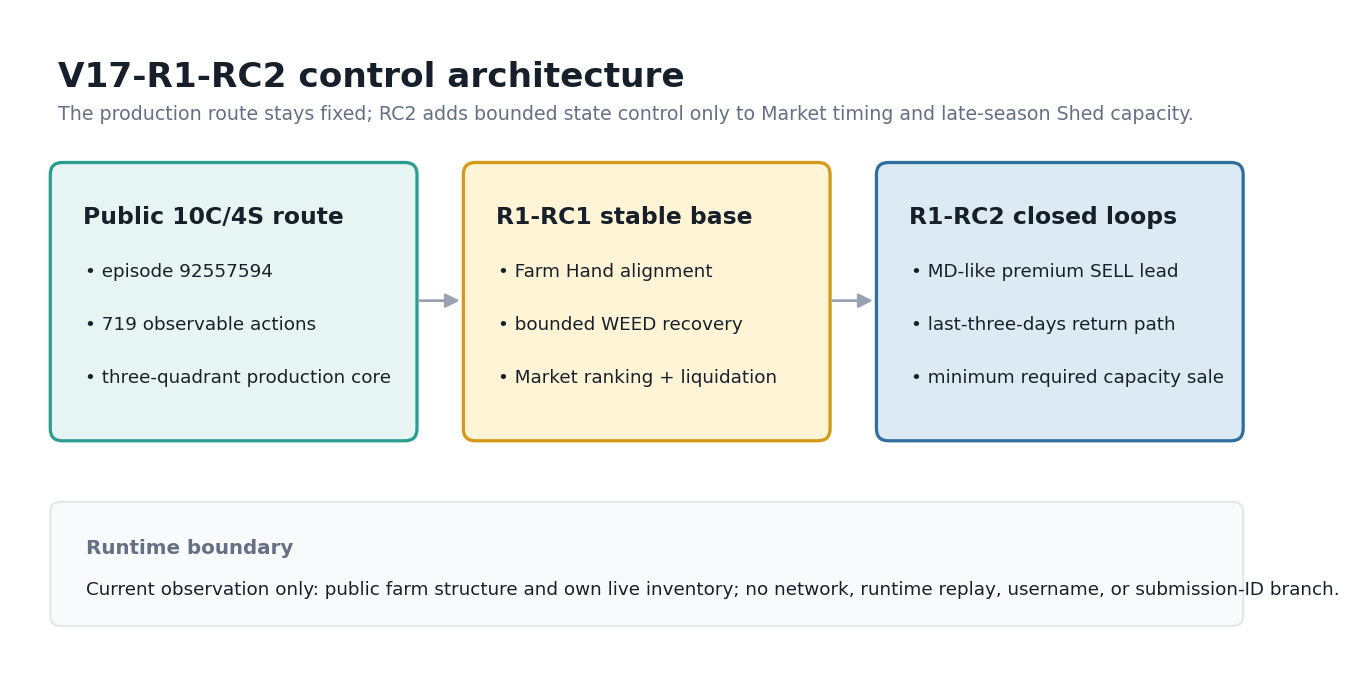

In [2]:
fig, ax = plt.subplots(figsize=(12.8, 6.5))
ax.set_xlim(0, 12.8)
ax.set_ylim(0, 6.5)
ax.axis("off")

ax.text(0.45, 6.02, "V17-R1-RC2 control architecture", fontsize=19, fontweight="bold", va="top")
ax.text(
    0.45, 5.58,
    "The production route stays fixed; RC2 adds bounded state control only to Market timing and late-season Shed capacity.",
    fontsize=10.5, color=GREY, va="top",
)

stages = [
    (0.45, "Public 10C/4S route", ["episode 92557594", "719 observable actions", "three-quadrant production core"], TEAL, TEAL_LIGHT),
    (4.55, "R1-RC1 stable base", ["Farm Hand alignment", "bounded WEED recovery", "Market ranking + liquidation"], GOLD, GOLD_LIGHT),
    (8.65, "R1-RC2 closed loops", ["MD-like premium SELL lead", "last-three-days return path", "minimum required capacity sale"], BLUE, BLUE_LIGHT),
]
for x, title, lines, edge, fill in stages:
    box = FancyBboxPatch((x, 2.30), 3.48, 2.62, boxstyle="round,pad=0.08,rounding_size=0.12",
                         facecolor=fill, edgecolor=edge, linewidth=1.8)
    ax.add_patch(box)
    ax.text(x + 0.24, 4.57, title, fontsize=13, fontweight="bold", va="top")
    for index, line in enumerate(lines):
        ax.text(x + 0.26, 4.00 - index * 0.53, "• " + line, fontsize=10.2, va="top")
for left, right in zip(stages, stages[1:]):
    ax.add_patch(FancyArrowPatch((left[0] + 3.55, 3.62), (right[0] - 0.08, 3.62),
                                 arrowstyle="-|>", mutation_scale=16, color=QUIET, linewidth=1.5))

boundary = FancyBboxPatch((0.45, 0.45), 11.68, 1.08, boxstyle="round,pad=0.08,rounding_size=0.10",
                          facecolor=OFF_WHITE, edgecolor=GRID, linewidth=1.2)
ax.add_patch(boundary)
ax.text(0.72, 1.25, "Runtime boundary", fontsize=11, fontweight="bold", color=GREY, va="top")
ax.text(
    0.72, 0.83,
    "Current observation only: public farm structure and own live inventory; no network, runtime replay, username, or submission-ID branch.",
    fontsize=10.2, va="top",
)
fig.savefig("v17_architecture.png", bbox_inches="tight", facecolor="white")
plt.show()

## 2. Bounded Market and Shed control

### Public-structure gates

The agent identifies route structures from visible quadrant, `COW`, and `SHEEP` counts. It never keys on a player name or submission ID.

The RC2 MD-like gate latches from step 160 when the opponent has at least two unlocked quadrants with `COW >= 4` and `SHEEP <= 2`, or when `COW >= 9`. Once active, it considers only `MELON`, `MILK`, `STRAWBERRY`, and `WOOL` scheduled for sale on the next turn.

Every added `SELL` is constrained by:

- the player's live Shed inventory;
- inventory reserved for an existing `PICKUP`;
- any same-product `SELL` already present;
- the 10-order Market limit.

### Last-three-days capacity guard

The storage branch starts at step 648. At hour 21 it can redirect only an otherwise-`PASS` Farm Hand carrying saleable inventory within two moves of the Shed. At hour 23 it performs `DROP` and sells only the amount needed to remove projected overflow. A final day-end projection includes the live Shed, carried inventory, current production and consumption, and current Market orders.

After both overlays, SELL slots are ranked by current price impact and demand recovery. From step 716, terminal liquidation uses the live Shed state so saleable inventory is not stranded after the 720-turn season.

## 3. Public source structure

The route source is public episode `92557594`, seat 0. At frame 480, the farm has unlocked `NW`, `NE`, and `SW` and contains `33 STRAWBERRY`, `26 WHEAT`, `10 COW`, and `4 SHEEP` with 43,958 bank cash.

This is a source-route snapshot, not an online RC2 result.

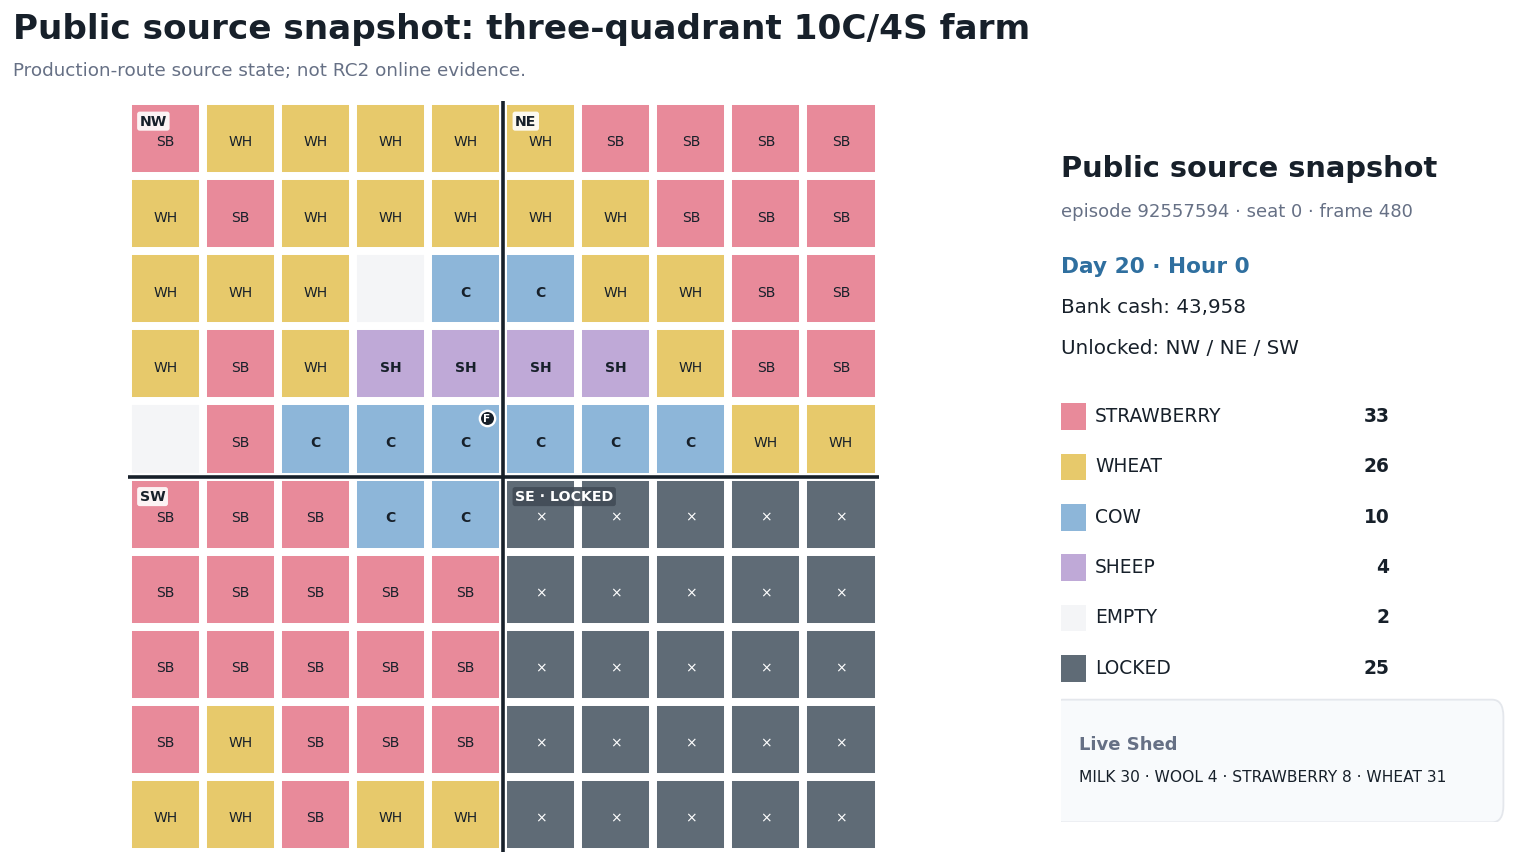

In [3]:
kind_colors = {
    "STRAWBERRY": "#E88A9A",
    "WHEAT": "#E7C96B",
    "COW": "#8DB6D9",
    "SHEEP": "#BFA9D7",
    "EMPTY": "#F4F5F7",
    "LOCKED": "#5F6B76",
}
kind_labels = {"STRAWBERRY": "SB", "WHEAT": "WH", "COW": "C", "SHEEP": "SH", "EMPTY": "", "LOCKED": "×"}

fig = plt.figure(figsize=(13.0, 7.6))
ax = fig.add_axes([0.07, 0.10, 0.58, 0.76])
info = fig.add_axes([0.69, 0.13, 0.27, 0.69])
ax.set_xlim(0, 10); ax.set_ylim(10, 0); ax.set_aspect("equal"); ax.axis("off")

for row_index, row in enumerate(BOARD["board"]):
    for col_index, kind in enumerate(row):
        ax.add_patch(Rectangle((col_index + 0.04, row_index + 0.04), 0.92, 0.92,
                               facecolor=kind_colors[kind], edgecolor="white", linewidth=1.1))
        label = kind_labels[kind]
        if label:
            ax.text(col_index + 0.5, row_index + 0.54, label, ha="center", va="center",
                    fontsize=7.7, fontweight="bold" if kind in ("COW", "SHEEP") else "normal",
                    color="white" if kind == "LOCKED" else INK)

ax.plot([5, 5], [0, 10], color=INK, linewidth=2.0)
ax.plot([0, 10], [5, 5], color=INK, linewidth=2.0)
for x, y, label in [(0.16, 0.32, "NW"), (5.16, 0.32, "NE"), (0.16, 5.32, "SW"), (5.16, 5.32, "SE · LOCKED")]:
    locked = "LOCKED" in label
    ax.text(x, y, label, fontsize=7.8, fontweight="bold", color="white" if locked else INK,
            bbox=dict(boxstyle="round,pad=0.18", facecolor="#414B56" if locked else "white",
                      edgecolor="none", alpha=0.90))

farmer_row, farmer_col = BOARD["farmer"]
ax.scatter(farmer_col + 0.78, farmer_row + 0.22, s=72, color=INK, edgecolor="white", linewidth=1.3, zorder=5)
ax.text(farmer_col + 0.78, farmer_row + 0.22, "F", ha="center", va="center",
        fontsize=5.8, fontweight="bold", color="white", zorder=6)

info.axis("off")
info.text(0.0, 0.98, "Public source snapshot", fontsize=16, fontweight="bold", va="top")
info.text(0.0, 0.91, "episode 92557594 · seat 0 · frame 480", fontsize=10, color=GREY, va="top")
info.text(0.0, 0.83, f"Day {BOARD['day']} · Hour {BOARD['hour']}", fontsize=12, fontweight="bold", color=BLUE, va="top")
info.text(0.0, 0.77, f"Bank cash: {BOARD['bank_cash']:,.0f}", fontsize=11, va="top")
info.text(0.0, 0.71, "Unlocked: NW / NE / SW", fontsize=11, va="top")

legend = [("STRAWBERRY", "STRAWBERRY"), ("WHEAT", "WHEAT"), ("COW", "COW"),
          ("SHEEP", "SHEEP"), ("EMPTY", "EMPTY"), ("LOCKED", "LOCKED")]
for index, (kind, label) in enumerate(legend):
    y = 0.60 - index * 0.074
    info.add_patch(Rectangle((0.0, y - 0.024), 0.055, 0.039, transform=info.transAxes,
                             facecolor=kind_colors[kind], edgecolor="none"))
    info.text(0.075, y - 0.003, label, fontsize=10.3, va="center")
    info.text(0.72, y - 0.003, str(BOARD["counts"][kind]), fontsize=10.3,
              fontweight="bold", ha="right", va="center")

box = FancyBboxPatch((0.0, 0.02), 0.95, 0.14, transform=info.transAxes,
                     boxstyle="round,pad=0.02,rounding_size=0.025",
                     facecolor=OFF_WHITE, edgecolor=GRID, linewidth=1.0)
info.add_patch(box)
info.text(0.04, 0.128, "Live Shed", fontsize=10, fontweight="bold", color=GREY, va="top")
info.text(0.04, 0.078,
          f"MILK {BOARD['shed']['MILK']} · WOOL {BOARD['shed']['WOOL']} · "
          f"STRAWBERRY {BOARD['shed']['STRAWBERRY']} · WHEAT {BOARD['shed']['WHEAT']}",
          fontsize=8.6, va="top")

fig.text(0.07, 0.95, "Public source snapshot: three-quadrant 10C/4S farm",
         fontsize=19, fontweight="bold", va="top")
fig.text(0.07, 0.90, "Production-route source state; not RC2 online evidence.",
         fontsize=10.2, color=GREY, va="top")
fig.savefig("public_source_board.png", bbox_inches="tight", facecolor="white")
plt.show()

## 4. Paired-seat evaluation protocol

All displayed games use the official `kaggle-environments==1.32.6` release and the competition configuration:

```text
episodeSteps = 720
townCenterSellInterval = 24
farmHandCostMult = 1
```

Each seed is run twice with the seat order reversed. The winner is determined by final bank cash. The two seat margins for one opponent and seed are then averaged to obtain the paired result.

Two benchmark categories are reported separately:

| Benchmark | Purpose | Non-duplicate executable references |
|---|---|---|
| **Frozen benchmark** | Fixed historical mainstream strategies retained as a stable comparison set | Kaito V27, Salem, BL-V14, V16-R6-RC1 |
| **Live-meta benchmark** | Executable representatives of mainstream families observed in the current Top-20 survey | R5A, Hamed-R0, MD/gogogo |

The live-meta family assignment is timestamped **2026-08-13 16:00:05 JST**. It is a local test against executable family representatives selected from that ladder snapshot, not a continuously refreshed leaderboard sample. It does not cover the adaptive Kawashigi controller or the researchstudio.site adaptive livestock route.

RC5-R1 remains visible in the raw tables, but it is excluded from every primary total because its game-level results are identical to R5A in this panel. The 96-game raw development panel and the 160-game raw holdout use disjoint seeds. The final candidate was frozen before the holdout, the holdout was run once, and no parameter was changed afterward.

,test_group,family,Evidence,RC1 W-L,RC1 mean margin,RC2 W-L,RC2 mean margin
reference,,,,,,,
R5A,Live-meta benchmark,Nikita-derived 8C/4S,Primary,10-2,"+3,307.50",10-2,"+3,534.92"
RC5-R1,Live-meta benchmark,Nikita-derived 8C/4S,Duplicate (excluded),10-2,"+3,307.50",10-2,"+3,534.92"
Hamed-R0,Live-meta benchmark,Nikita-derived 8C/4S,Primary,10-2,"+3,899.58",10-2,"+4,127.67"
MDgogo,Live-meta benchmark,Kawashigi-opening 10C/4S,Primary,5-7,+135.67,12-0,"+1,793.17"
Kaito-v27,Frozen benchmark,Historical public frontier,Primary,12-0,"+3,876.92",10-2,"+3,291.67"
Salem,Frozen benchmark,Historical public frontier,Primary,10-2,"+3,637.42",10-2,"+3,791.58"
BL-V14,Frozen benchmark,Historical Boatlee frontier,Primary,8-4,"+2,783.00",8-4,"+2,978.00"
V16-R6-RC1,Frozen benchmark,Historical Boatlee frontier,Primary,8-4,"+1,759.08",8-4,"+1,951.25"


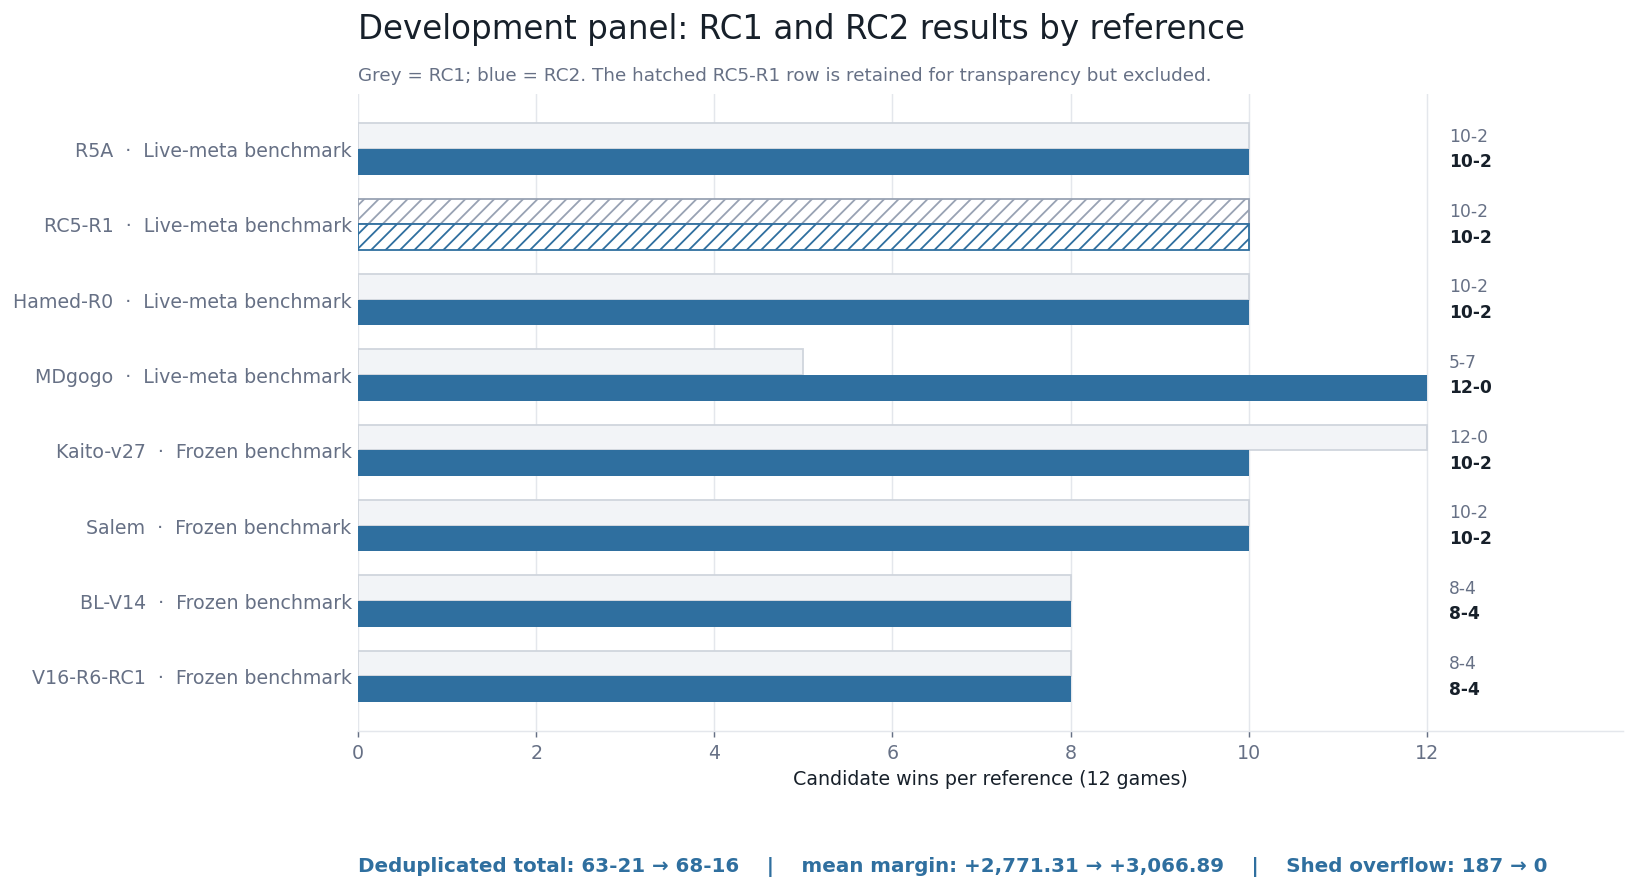

In [4]:
development_table = DEVELOPMENT.copy()
development_table["RC1 W-L"] = development_table.apply(
    lambda row: f'{int(row["rc1_wins"])}-{int(row["rc1_losses"])}', axis=1)
development_table["RC2 W-L"] = development_table.apply(
    lambda row: f'{int(row["rc2_wins"])}-{int(row["rc2_losses"])}', axis=1)
development_table["RC1 mean margin"] = development_table["rc1_mean_margin"].map(lambda value: f"{value:+,.2f}")
development_table["RC2 mean margin"] = development_table["rc2_mean_margin"].map(lambda value: f"{value:+,.2f}")
development_table["Evidence"] = development_table["include_in_summary"].map(
    {True: "Primary", False: "Duplicate (excluded)"})
display(development_table[["reference", "test_group", "family", "Evidence", "RC1 W-L", "RC1 mean margin", "RC2 W-L", "RC2 mean margin"]].set_index("reference"))

fig, ax = plt.subplots(figsize=(12.8, 7.2))
fig.subplots_adjust(left=0.20, right=0.96, top=0.86, bottom=0.18)
y = np.arange(len(DEVELOPMENT)); height = 0.34
included = DEVELOPMENT["include_in_summary"].astype(bool)
ax.barh(y[included] - height / 2, DEVELOPMENT.loc[included, "rc1_wins"], height=height,
        color=PALE, edgecolor="#D0D5DD", label="RC1")
ax.barh(y[included] + height / 2, DEVELOPMENT.loc[included, "rc2_wins"], height=height,
        color=BLUE, label="RC2")
ax.barh(y[~included] - height / 2, DEVELOPMENT.loc[~included, "rc1_wins"], height=height,
        color="white", edgecolor=QUIET, hatch="///", label="Duplicate reference")
ax.barh(y[~included] + height / 2, DEVELOPMENT.loc[~included, "rc2_wins"], height=height,
        color="white", edgecolor=BLUE, hatch="///")
for index, row in DEVELOPMENT.iterrows():
    ax.text(12.25, index - height / 2, f'{int(row["rc1_wins"])}-{int(row["rc1_losses"])}',
            fontsize=9.5, va="center", color=GREY)
    ax.text(12.25, index + height / 2, f'{int(row["rc2_wins"])}-{int(row["rc2_losses"])}',
            fontsize=9.5, va="center", color=INK, fontweight="bold")
labels = [f'{row["reference"]}  ·  {row["test_group"]}' for _, row in DEVELOPMENT.iterrows()]
ax.set_yticks(y, labels); ax.invert_yaxis(); ax.set_xlim(0, 14.2)
ax.set_xticks([0, 2, 4, 6, 8, 10, 12]); ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True); ax.spines[["top", "right", "left"]].set_visible(False); ax.tick_params(axis="y", length=0)
ax.set_xlabel("Candidate wins per reference (12 games)")
ax.set_title("Development panel: RC1 and RC2 results by reference", loc="left", fontsize=18, pad=31)
ax.text(0, 1.015, "Grey = RC1; blue = RC2. The hatched RC5-R1 row is retained for transparency but excluded.",
        transform=ax.transAxes, fontsize=10.2, color=GREY, va="bottom")
fig.text(0.20, 0.025,
         "Deduplicated total: 63-21 → 68-16    |    mean margin: +2,771.31 → +3,066.89    |    Shed overflow: 187 → 0",
         fontsize=11, fontweight="bold", color=BLUE, va="bottom")
fig.savefig("development_panel.png", bbox_inches="tight", facecolor="white")
plt.show()

,test_group,family,Evidence,W-L,Paired +/-,Mean margin,Minimum margin
reference,,,,,,,
R5A,Live-meta benchmark,Nikita-derived 8C/4S,Primary,20-0,10/0,"+8,443.10","+1,344"
RC5-R1,Live-meta benchmark,Nikita-derived 8C/4S,Duplicate (excluded),20-0,10/0,"+8,443.10","+1,344"
Hamed-R0,Live-meta benchmark,Nikita-derived 8C/4S,Primary,20-0,10/0,"+9,014.45","+1,868"
MDgogo,Live-meta benchmark,Kawashigi-opening 10C/4S,Primary,20-0,10/0,"+3,191.25",+245
Kaito-v27,Frozen benchmark,Historical public frontier,Primary,20-0,10/0,"+10,080.90","+2,420"
Salem,Frozen benchmark,Historical public frontier,Primary,20-0,10/0,"+9,496.30","+1,446"
BL-V14,Frozen benchmark,Historical Boatlee frontier,Primary,20-0,10/0,"+12,002.30","+4,841"
V16-R6-RC1,Frozen benchmark,Historical Boatlee frontier,Primary,18-2,9/1,"+6,469.95","-1,386"


,references,W-L,Paired +/-,Mean margin
benchmark,,,,
Live-meta benchmark,"R5A, Hamed-R0, MDgogo",60-0,30/0,"+6,882.93"
Frozen benchmark,"Kaito-v27, Salem, BL-V14, V16-R6-RC1",78-2,39/1,"+9,512.36"


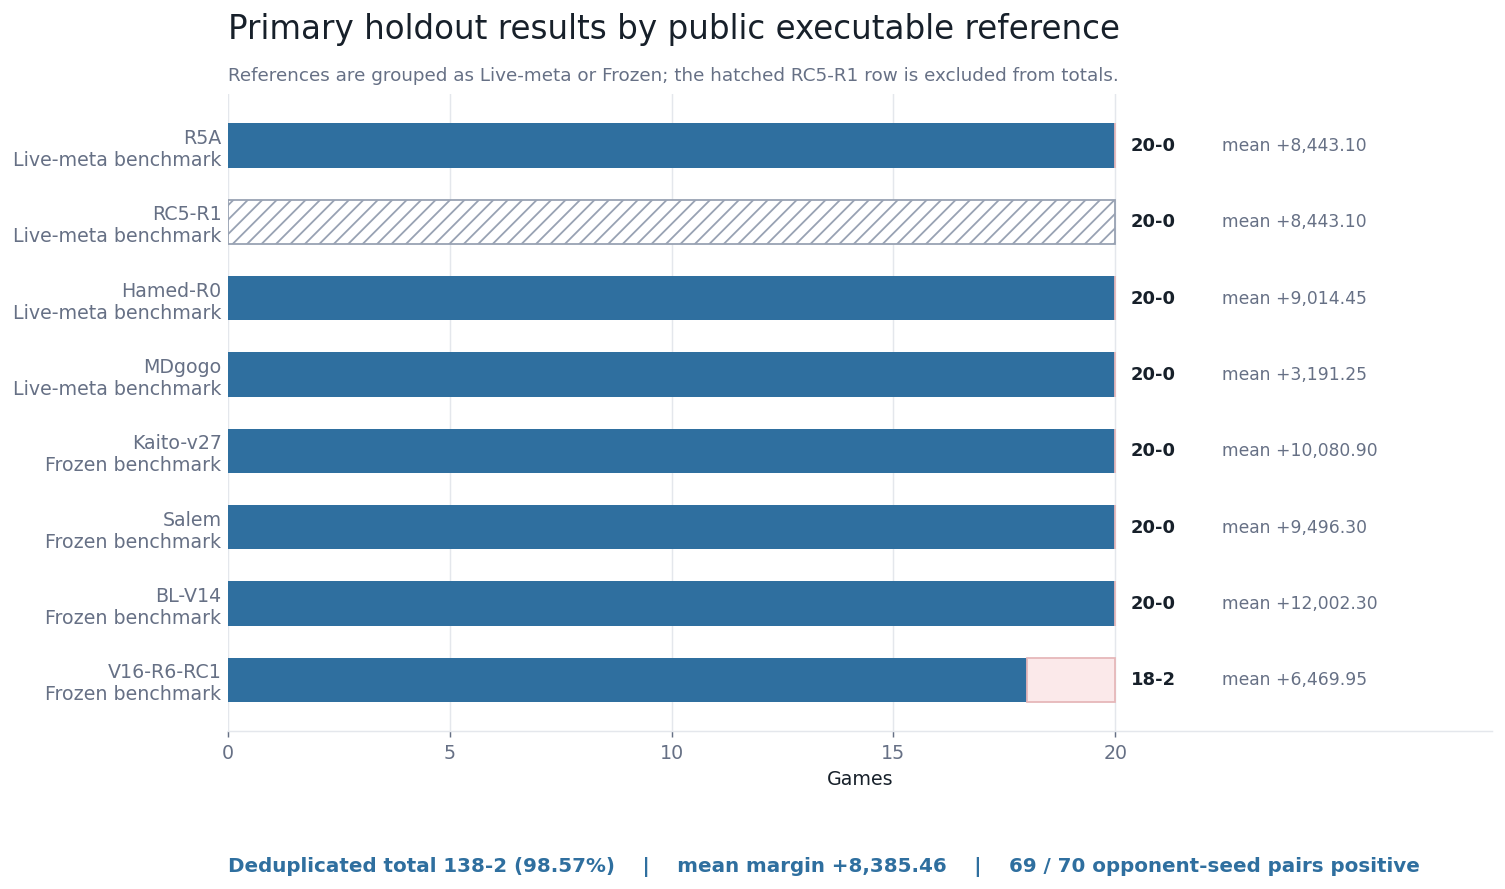

In [5]:
final_table = FINAL_HOLDOUT.copy()
final_table["W-L"] = final_table.apply(lambda row: f'{int(row["wins"])}-{int(row["losses"])}', axis=1)
final_table["Paired +/-"] = final_table.apply(
    lambda row: f'{int(row["paired_positive"])}/{int(row["paired_negative"])}', axis=1)
final_table["Mean margin"] = final_table["mean_margin"].map(lambda value: f"{value:+,.2f}")
final_table["Minimum margin"] = final_table["minimum_margin"].map(lambda value: f"{value:+,.0f}")
final_table["Evidence"] = final_table["include_in_summary"].map(
    {True: "Primary", False: "Duplicate (excluded)"})
display(final_table[["reference", "test_group", "family", "Evidence", "W-L", "Paired +/-", "Mean margin", "Minimum margin"]].set_index("reference"))

group_table = BENCHMARK_GROUPS.copy()
group_table["W-L"] = group_table.apply(lambda row: f'{int(row["wins"])}-{int(row["losses"])}', axis=1)
group_table["Paired +/-"] = group_table.apply(
    lambda row: f'{int(row["paired_positive"])}/{int(row["paired_negative"])}', axis=1)
group_table["Mean margin"] = group_table["mean_margin"].map(lambda value: f"{value:+,.2f}")
display(group_table[["benchmark", "references", "W-L", "Paired +/-", "Mean margin"]].set_index("benchmark"))

fig, ax = plt.subplots(figsize=(12.8, 7.2))
fig.subplots_adjust(left=0.20, right=0.96, top=0.86, bottom=0.18)
y = np.arange(len(FINAL_HOLDOUT))
included = FINAL_HOLDOUT["include_in_summary"].astype(bool)
ax.barh(y[included], FINAL_HOLDOUT.loc[included, "wins"], color=BLUE, height=0.58, label="Win")
ax.barh(y[included], FINAL_HOLDOUT.loc[included, "losses"], left=FINAL_HOLDOUT.loc[included, "wins"],
        color=RED_LIGHT, edgecolor="#E6B8BA", height=0.58, label="Loss")
ax.barh(y[~included], FINAL_HOLDOUT.loc[~included, "wins"], color="white", edgecolor=QUIET,
        hatch="///", height=0.58, label="Duplicate reference")
for index, row in FINAL_HOLDOUT.iterrows():
    ax.text(20.35, index, f'{int(row["wins"])}-{int(row["losses"])}', fontsize=10, fontweight="bold", va="center")
    ax.text(22.4, index, f'mean {row["mean_margin"]:+,.2f}', fontsize=9.5, color=GREY, va="center")
labels = [f'{row["reference"]}\n{row["test_group"]}' for _, row in FINAL_HOLDOUT.iterrows()]
ax.set_yticks(y, labels); ax.invert_yaxis(); ax.set_xlim(0, 28.5)
ax.set_xticks([0, 5, 10, 15, 20]); ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True); ax.spines[["top", "right", "left"]].set_visible(False); ax.tick_params(axis="y", length=0)
ax.set_xlabel("Games")
ax.set_title("Primary holdout results by public executable reference", loc="left", fontsize=18, pad=31)
ax.text(0, 1.015, "References are grouped as Live-meta or Frozen; the hatched RC5-R1 row is excluded from totals.",
        transform=ax.transAxes, fontsize=10.2, color=GREY, va="bottom")
fig.text(0.20, 0.025,
         "Deduplicated total 138-2 (98.57%)    |    mean margin +8,385.46    |    69 / 70 opponent-seed pairs positive",
         fontsize=11, fontweight="bold", color=BLUE, va="bottom")
# Keep the footer inside the fixed figure canvas.  A tight bounding box can
# shift figure-level text past the left edge in Kaggle's rendered artifact.
fig.savefig("final_holdout.png", facecolor="white")
plt.show()

,references,Positive / negative,Mean paired margin,Pair range
seed,,,,
81013,7,7 / 0,"+7,200.57","+3,256 to +9,616"
81331,7,7 / 0,"+6,705.57","+1,514 to +9,689"
81647,7,7 / 0,"+5,765.86","+1,887 to +8,724"
81967,7,7 / 0,"+9,186.93","+1,706 to +19,693"
82283,7,7 / 0,"+9,554.36","+1,190 to +14,278"
82601,7,7 / 0,"+8,782.93","+1,108 to +17,773"
82921,7,7 / 0,"+10,173.29","+2,366 to +12,479"
83239,7,6 / 1,"+2,283.86","-1,386 to +6,398"
83557,7,7 / 0,"+7,950.71","+3,854 to +15,726"


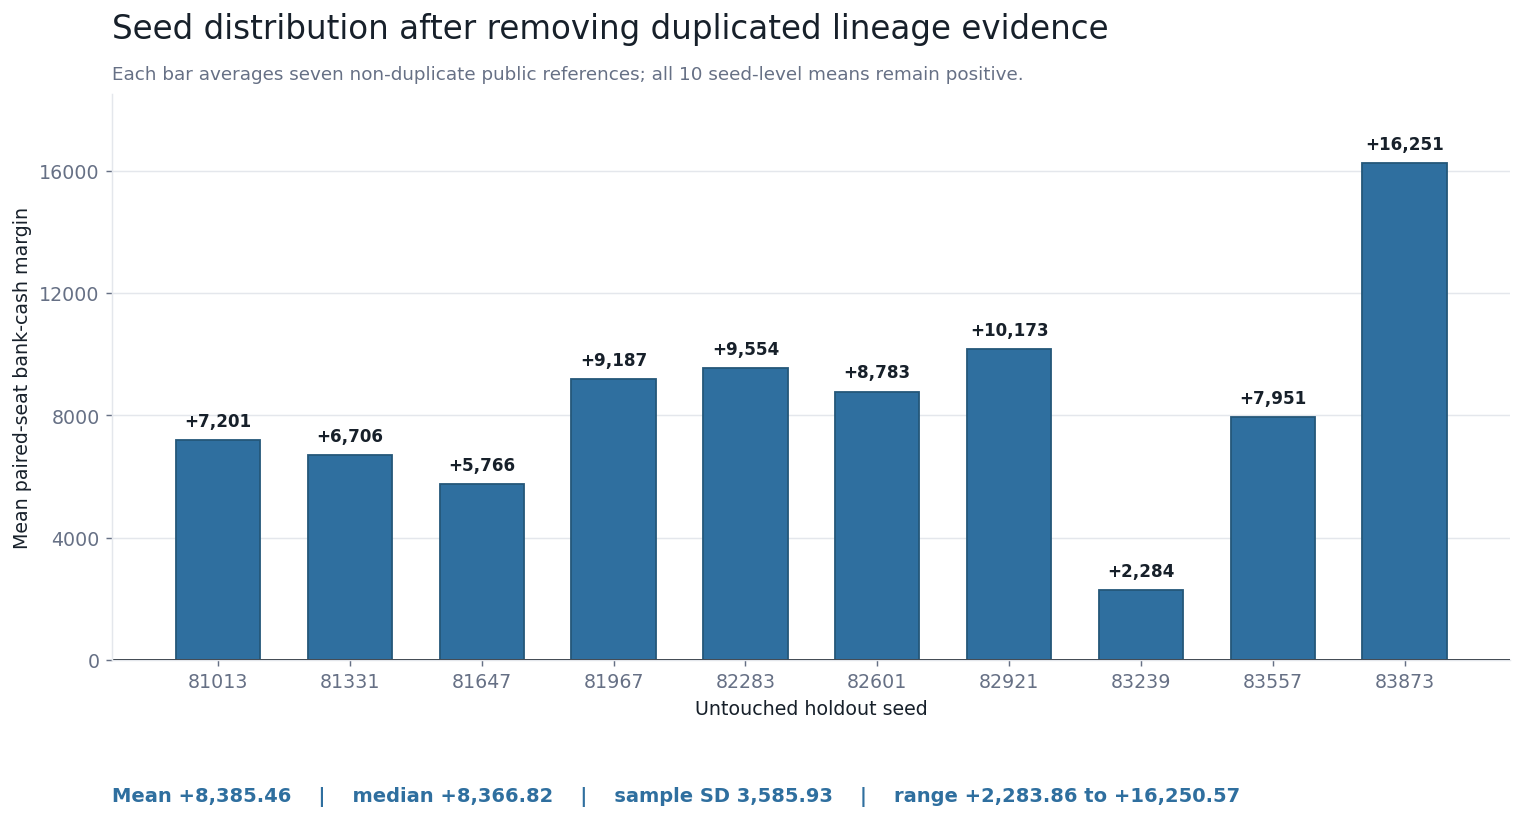

In [6]:
seed_table = SEED_DISTRIBUTION.copy()
seed_table["Mean paired margin"] = seed_table["mean_margin"].map(lambda value: f"{value:+,.2f}")
seed_table["Pair range"] = seed_table.apply(
    lambda row: f'{row["minimum_pair_margin"]:+,.0f} to {row["maximum_pair_margin"]:+,.0f}', axis=1)
seed_table["Positive / negative"] = seed_table.apply(
    lambda row: f'{int(row["positive_pairs"])} / {int(row["negative_pairs"])}', axis=1)
display(seed_table[["seed", "references", "Positive / negative", "Mean paired margin", "Pair range"]].set_index("seed"))

fig, ax = plt.subplots(figsize=(12.8, 6.8))
fig.subplots_adjust(left=0.12, right=0.96, top=0.84, bottom=0.20)
x = np.arange(len(SEED_DISTRIBUTION))
ax.bar(x, SEED_DISTRIBUTION["mean_margin"], color=BLUE, edgecolor="#245779", width=0.64)
ax.axhline(0, color=INK, linewidth=1.1)
for index, row in SEED_DISTRIBUTION.iterrows():
    ax.text(index, row["mean_margin"] + 320, f'{row["mean_margin"]:+,.0f}', ha="center", va="bottom",
            fontsize=9.3, fontweight="bold")
ax.set_xticks(x, SEED_DISTRIBUTION["seed"].astype(str), rotation=0)
ax.set_ylim(0, 18500)
ax.set_yticks([0, 4000, 8000, 12000, 16000])
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True); ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Untouched holdout seed")
ax.set_ylabel("Mean paired-seat bank-cash margin")
ax.set_title("Seed distribution after removing duplicated lineage evidence", loc="left", fontsize=18, pad=31)
ax.text(0, 1.02, "Each bar averages seven non-duplicate public references; all 10 seed-level means remain positive.",
        transform=ax.transAxes, fontsize=10.2, color=GREY, va="bottom")
fig.text(0.12, 0.035,
         "Mean +8,385.46    |    median +8,366.82    |    sample SD 3,585.93    |    range +2,283.86 to +16,250.57",
         fontsize=10.8, fontweight="bold", color=BLUE, va="bottom")
fig.savefig("seed_distribution.png", bbox_inches="tight", facecolor="white")
plt.show()

### Result interpretation and safety

After removing RC5-R1 from the primary summary, the result is `138-2 / 140 games` and `69 positive / 1 negative` opponent-seed pairs. The two losses came from both seat orders of one seed against V16-R6-RC1.

Across the seven non-duplicate references, all ten seed-level mean margins are positive. Their mean is `+8,385.46`, median `+8,366.82`, sample standard deviation `3,585.93`, and range `+2,283.86` to `+16,250.57`. Across the 70 individual opponent-seed paired margins, the sample standard deviation is `5,236.70`, with a range from `-1,386` to `+19,693`.

The complete raw panel remains `158-2 / 160` and `79 positive / 1 negative` opponent-seed pairs. R5A and RC5-R1 are separate public artifacts, but they produced identical game-level results here; retaining both in a headline total would double-weight the same lineage.

Across all 160 candidate appearances:

| Safety metric | Total |
|---|---:|
| failed game / timeout | 0 / 0 |
| invalid / malformed action | 0 / 0 |
| over-limit Market order | 0 |
| Shed overflow | 0 |
| final unsold value | 0 |
| escaped animal | 1 |
| maximum single-turn runtime | 0.091466 s |

The single animal escape occurred in a win against MD/gogogo and was not accompanied by overflow, unsold value, or a runtime failure.

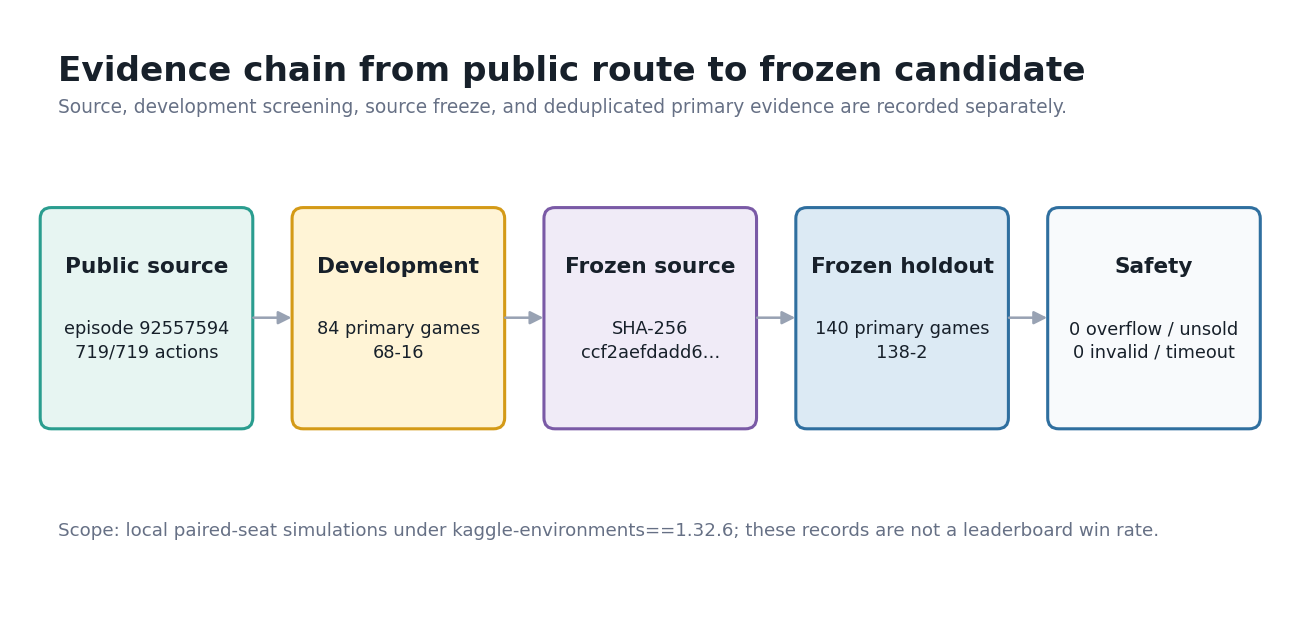

In [7]:
fig, ax = plt.subplots(figsize=(12.8, 6.1))
ax.set_xlim(0, 12.8); ax.set_ylim(0, 6.1); ax.axis("off")
ax.text(0.45, 5.68, "Evidence chain from public route to frozen candidate", fontsize=19, fontweight="bold", va="top")
ax.text(0.45, 5.25, "Source, development screening, source freeze, and deduplicated primary evidence are recorded separately.",
        fontsize=10.3, color=GREY, va="top")
stages = [
    (0.35, "Public source", "episode 92557594\n719/719 actions", TEAL, TEAL_LIGHT),
    (2.85, "Development", "84 primary games\n68-16", GOLD, GOLD_LIGHT),
    (5.35, "Frozen source", "SHA-256\nccf2aefdadd6…", PURPLE, "#F0EBF7"),
    (7.85, "Frozen holdout", "140 primary games\n138-2", BLUE, BLUE_LIGHT),
    (10.35, "Safety", "0 overflow / unsold\n0 invalid / timeout", BLUE, OFF_WHITE),
]
for x, title, body, edge, fill in stages:
    box = FancyBboxPatch((x, 2.02), 1.95, 2.05, boxstyle="round,pad=0.08,rounding_size=0.11",
                         facecolor=fill, edgecolor=edge, linewidth=1.7)
    ax.add_patch(box)
    ax.text(x + 0.975, 3.66, title, fontsize=12.0, fontweight="bold", ha="center", va="top")
    ax.text(x + 0.975, 3.03, body, fontsize=9.8, ha="center", va="top", linespacing=1.40)
for left, right in zip(stages, stages[1:]):
    ax.add_patch(FancyArrowPatch((left[0] + 2.0, 3.05), (right[0] - 0.05, 3.05),
                                 arrowstyle="-|>", mutation_scale=15, linewidth=1.4, color=QUIET))
ax.text(0.45, 1.02,
        "Scope: local paired-seat simulations under kaggle-environments==1.32.6; these records are not a leaderboard win rate.",
        fontsize=10.1, color=GREY, va="top")
fig.savefig("evidence_chain.png", bbox_inches="tight", facecolor="white")
plt.show()

## 5. Provenance and complete implementation

1. **Public replay reconstruction:** the fixed 719-action production sequence is reconstructed from public episode `92557594`, seat 0. This reproduces observed actions; it does not claim access to the source player's hidden policy.
2. **Prior public work in this series:** Farm Hand alignment, projected-Shed accounting, price-impact SELL ranking, and terminal liquidation continue from [V14 Clone Preemption](https://www.kaggle.com/code/boatlee/84-84-base-public-holdout-v14-clone-preemption) and later public releases.
3. **RC1 public-state control:** the earlier R5-like branch uses visible farm structure and live own inventory under fixed order and quantity limits.
4. **RC2 engineering:** the MD-like premium SELL lead and the late-season Shed-capacity guard are implemented on top of the frozen route and require no runtime file access.
5. **Executable references:** the raw holdout includes public artifacts or public-behavior reconstructions for R5A, RC5-R1, Hamed-R0, MD/gogogo, [Kaito V27](https://www.kaggle.com/code/kaitofukami/25-27-strict-future-v27-midgame-meta-reset), [Salem](https://www.kaggle.com/code/salemali7/3094-score-kaggriculture), BL-V14, and V16-R6-RC1. Primary summaries exclude RC5-R1 as duplicated lineage evidence.

At runtime, the agent uses only the Python standard library and the current observation. It does not access the network or read replay files.

Frozen `main.py` SHA-256: `ccf2aefdadd600d3e6fcaad2879a310eb15bbd14183fc2deeff9bb2525697b9a`

The next cell writes the exact competition agent.

In [8]:
%%writefile main.py
"""BL-MDgogo-10C4S-R0: public-replay consensus route with generic execution guards.

This is a behavioral reconstruction from twelve public traces, not either
team's hidden source policy. Clone preemption is disabled in this experiment.
"""
import base64
import copy
import json
import math
import zlib


_ACTIONS = json.loads(zlib.decompress(base64.b85decode('c-rk<O>Z38k^C<_^PpyT^J8xusl5`+8448ThCLt#1K0}#hW9YLw}t=v%4C03)r*Xb%zQ<11m0TBR@M7{nURr^KmXs!fBpK~KmYdI$$$KO^266pHy?iaeEsGA>)qz$;q>J1zy9}M|L5CZzJ2`XufP4{Z~y!4^Uo(AKRy0c`|!ipKmT(5)2AP=Z%$56-rsIdPS2XJzkJ+mJ`euzWwZJ4?d$Ew&Gr4s>BZ#hA2&C*Kb@Q|4nO~Vcl+V%`}^bnIDdHf*XgihpFh3-<JZr}H!TKz`}t(M`Evi*)}L<g?ms?$I(#+xFdm36o12^CTbI+f?jJXJ6==xtwZ~7>sXz^wyw03G*uz6h9_M5+>g(=T<XxX{uHSF0@kIUE{|E54NxR8gcmHKLo=rO*zx(O97)E{F&6M#ocZ4_B)At{j$MyZ@Zn}u3-;GxfT)Jn|MfBzN>vR#di}Mfv-Wj8BCcR@**$&QlfG4AL?BDzA-O}9u=xJvTx*nR#<8ZYv-H*cXSMGFy{f8z8?1W|oleg@~9*o&wIGP!2f1}UXZrth6jh;K*dB-7ar^#5C3*m4Bo54I<`Pnk+f;O_~(D5g4-%@=n<!}6X1VgwxVZa=D^QI5t;T?w$-_G7I=tFGaj^kc=@a~s%()&K2PI#9N?EmlJO<kYset3b$PHvT@VNE)RY2X6s^VI3t8ri<j-h!z;LVntq5q(<l{`Tf(^Zx#qKWy&qKiz!#%lJ&_G<fNk1eQqp9W%|r{?;C}$J|2)M`ZG2<0@Z21T4T;z5WC9JMH5t@7=ogU(qH3=3Qex4vcWHa5H`eFh<~>z`fcn?U0$w`!MXS*GG2%fny&qNSUhwKY0&iV}U-o4`d#JXg?PGQM<`W2g)8)$@Wz?5cSRd`6r%E&Gl7)C--sCTMjr6z_>p?vNZ<%&EEni#J2R?7kZp)suJAnnGNf=r}clDeD4DrYNdkQdBecA723mj45Ke5u=uxA@9q{MHPUg&u3G7k%-9cyw+;@h_}wYCz0$eR5F%u~bSKdJwPbA2i#9VX+>SA!$cWSAwLf4sQOkpv3<-OTF8U+t=VGG-y>bS_hYTYJ?-a`Vet@gD$G$!GclcNx!0KV@*pYV_!gnF3br?V~Lh|jq8xNMba~i&q^cn+rN-Y5CSwtBSB!)^w+E1eDRY#Ux@W$ADyuSOB)v<mzegG{Hqu6Mu4t+@u(Qqs(6oYnf+8E@4Oi%(+_@Ey;_Vm`+pd+K|Fet;3^5GDGuZ))6agFW=<rwjl2mSa&bkz*sH!#q33}(vFp!XSgLngx9KDebxy_pSfkFA14YtM4p{qFK{ySK*F8WSHE5z}gC#C*BGyWak=xx4!_uw+sQliMNl?U06f)*WtQ4Ky0Dc$fi=dPWc`baw{K$SD++y-RImAqzasWnvAjlOfg=Lzp<IQd%E}4~Hw=f1HN1?Qi74rp4sfj-k$ycQPG;<SMZG9s2sInOTbveR^tWCdAs_a)j_EaJ3_k%fN)Q(ed5_TQ3zRJC9&T>!Mw=d`KLhLcGke5s0CJj#tH*roOrd#$>J)hE@zN!R_ts&0|^&G_7`j+)dE8^YOz;+SWVz^SHNxucf0?GY1((q7!FjI@H#!ARD~nSqZP@!$gRn9E>Gj2<#t_snpw0NKFy*L$vsqdS6R0REZv@`z|$hR2%(tkunLrZ9b*(&W)8H5o;oVO{d}5SQ8P-IN(f;6AQ|_Akg`Cy3x@$JuNcZfDJSHqz?)>by@&<nmUtXd;y<iV&2YWMV$w;Wf!T4-8eS3@+~izu^KkVM9P%r=*r=(39ljsh@k9UkZo$T0bIZAI@8e##h>;D$oRUw$&DX!NWnNSmXXPZ8M}UZcFaPM?roZpXH&ftNPz)lhsaU@?E~|F?POFl;`kx>L^7J4{L+f`z;+N#FxB(PSq^J>1;YPOG=NQZ`Kc3+Y*9h~mL)y}+i&f9>1CU>A?NAJf*<^mX7<FP7r+28ZH>@4w_Rq>HTxGcc__$DI@koBK^AUiX)CW}qk&-D<T<Cb0E~I!Y>SMu0b7IN&m6K~Ky|KXeE3;P|NfCmOEP#h<q^mU-!G60-UrEDgnf`Y3-Ahi8zF(5A)&Cf3E<B{o<|~m1Kh4PgRN7p-{Hy{qQREw4~#nE%u)FxO(=vDQ@Q<$SxVVFkAQ0cuFJy&?+xA`Ki&LsxAH7Msr{v&=~n^CcU$`DeG3sfkdXCZyk-@hVzB7KumT5fD^4GH*<mGuEiZ`Mgz|HOVJIQ>bWS-caAY6N^r11_041$8&!Le_LJx6ahDV7{Iu&!HLSwn~0n^rPLlRixTEvHE%{c>e-J(YAIgX@(TKTosC{4y(TiPtUWcXgOEp(rP8^f8wJGHOOzvY}0$?;8m$R?b7u94}R^=cj226Xmf9<AOUw&KBs)jC#vhX+mzg;v~&Bu-)HW!Ao+g><H_c+68SIExza6n7tMI&8-in;hnqR#kap5UKCo9x2tV9uPG6*&s%kc60?Vd}W;|<ae4v)g10QFgrZ&oX~S)kxkuMcimNH#fTY_ey*f%@xweKY-P%xY$$cGl7z|p_;wW^Ls;#P^i)cntfT8JKe549cqM_fLJ8)f-a{3GIJ7v=q8eT=<55t+9_kB+qq;=>d)KIlqbw(jpslazf&^kifN$3L#h@X`A$6ohTB|q1<8xjtMea#xlc;gzsZik5Y2xN+Xu;03wXoS!s~)sAtWaOOwT=^XGl3+|@=jsGOehu;kx~IkD#TZStcpYsOtG62(rM4(Z77pD(}&_TK0~YWr_O5_L|}rwhGxAD*4y@+2bqw4{<QB4>Y%)uuzA}y8a5X~)-hifbwjszl?b}rN)`vn1duKsYC^}!+$>=Fs~m?MsGf2{V+?WXLuL4Efc!{fPCQ(P9#Yl~fUFAJCO=gYgUSVYTA!F<-L$m~lgiB{_iKl55o4{@OfCLscHZD-TMN_0Zm$9!ual$7$h}A+lPos_M)z$j;_jlY=xiW7)-b^kw0H6DA;F$y=wACHfG-@sf<brO)XO$RvGOk|8a;)l6hk34iim{V{Iv;KE*AcpXY0t7eZ}*_a6GwJ=MS0iKY_+TX4RhSHmuIrZ*`3x>vXQ&FQZIM(oCAVN(g%-1WkM3&D+9WjqAWZlkRaoGF)=7bGMg)oknH_OkEqO_RM)WEFg<n?(q7dqnH%UmV)T8S<Mm6VH@Jksmt3UN~c`Q2(iOx)fuVHfIP5quM=x6G|2?0&34YUzlKsB%7Gga&YK?fC>a9nqyd$h<VqhjOtSgWBjLMr-U3HuUN(oJrETi&v+JOnzGNrv1c=ZI^^8MUMl|p*;5U~M;gB|v2dT{6XQ--!b4-(fMVHZ+netzwGgZGP%~hXExM7qdZ{S&yVX7L3l-1hCq2qiTZd**)k{S8|a1ak2@P<{ROtZVXl7VFn!bV`k*B69&?r2toR!EHJA%K3Nhq$VhrDa3d5HxG%HLe(D6Vp9xB4%>sghc=~V5&#lAPy`FU+dIP&5%0C=z?v(@RId#El81Ji^~!wbGXL@*LFLg=&KkH;YUW+cZi9WDGFph8bW$kmM_!RueGRH_x!x7tRRZJXtbu%!VKY+au!Ld<FaoW=Euf7e21}snEQCzUb%xMRcrl35r;X}lO$`j(5fj25}2o%${Nhb6^sKmM{uStF3}TnIea;6&!q#=%#XnU#)BFxH6h@f6{=^Y<QXy|_M&J^ybC6&Q2RLUsDo&KNO7QD07<S<U1Yhc<HS~wj)j1jC}-~Y!NZh7GS!w)D{ac*=ZN<aDjjTi>FF#gHtlZq4I@&xeqN1quZVmHl2!tSG}-gw(6GJHQX`7lJ&e^=@q2|F(0~Xb(GVVZJESYHo?RvVA9GafNF~mZoaFJjgQi9W8PQ1#u(BbatO7}gSz80F`~#y_VV;T7_{lNb6P{q6dEALG1UHjRI93UjyY>3Iu>Ck)5xam}#~pnE#Yl`a6FA9(5sKVYc`1m)MYSQZ>x@#Jk_^tcch5)<(~fqTa1=AM$Q4rY%)$tEcJ048WLT@>cj4|o8|R|6=Ak7aB@WmaMZ)WEZILXmAS(D!m1kEoDv&8A6Do31NMP|N{e9QT%1lNPC}L6*)bENH0o9|Bn%af#v)Y1iNl@Q?b<5A#N)86273vNlg6P`BCbtuu+i4L^fsAlb3WD;!q}uWk#gp-6lTd_k1QjIN7KvUOq$9KC!Q=Qbtq8ZRtA|8kd3y4T(Mz`bHJ_Fp3KVpq91of@mG-|SJrF0L&K852Y9b&Xf|;%5;nBsw7kaj>L3&l|C8(}=+|@o4T&%V|)U9eiv|5WD8cIEDBI+nf74~oq&jQ&8Nk%>!SkXhwXBx1nS86)=OQ*{alW~+5ufA@2G`E_g5fdV<t%w|yaP|6F0z5MV-TWOP0gPM&!Tbi(DAhy-j-6-c!=OjOh291O_w_;$rM!lu53g6JC<{FhXPq+2_0clo*{3pJgXJoO>v$-zlS&&{q{_fBv|-OdZ}HN@H=$uZf2icA#Jsf7t_8^&8rwcl;DOABRCT~uC*zsOPz~B4KMu$E=|Xl#4*as~?`0hD3^zs6xv3SxR?~n)xy;N|GmQ|qkQ_2XCUcOM^Yg@LD3B-u9A~)`T}pcjOS~*Y(KlVIN2DHW>@KC$siVzPAlj@V4nFmkZN^OuE_>2VUaSm1;35L`aE@LeT_T)rAW<j);Kf|F=S#3}g1WCXc6-sqD|^<^ZLB6(As2pzAa1fEV2qQkuvxsJ#ZEJ|4T?l<5UI;E;vF3^p5R`jX}7CoT&?g)btB+)>*@MT_+;?zVgN{9+kpZCQXT9Hp%mF8R6o@drSnFiRBXx@W@z=$s2@UUvei8RB0hTFfeU(tD=zBtUDSrxw4j_wQ`U%76!65Tt2BOHLa~yZVr-xt9(bJ+O;$%lEYpd?QciW()gh@GgghYrD0Sd3iWF&{E5@WB?Fg{Y=+m;VqB+Dg`p-PWs7HTQY&*3iDH4*VR9~gp>am`XKqO*A4Lknf(|<;Kv^eYCcFY!kDiu6XTsyZeFKdbUU0Dw-%H~zVtU+f+(p5Y<`0Z3Se>!}F*K6mcIBm95O>x*Jz)nZBi;YK2h{TuH>JDp>qV8$*a4cdHy>lQsBZzi^brUBNvkPNqoW0gSe2%VP3dwUVbJOtd7m4@MZ8u?Qz$)?Htur3fu$?CuA1_3itb16JTA-fZEVVXT`_n5z8log8+3_qo<oVj2%6E7R3Ru8W`gk&LU87#}dXbwR<;|Jfh(Rld+n`Sg?dL?2`P{ef$sK)oNG&Oy<!@<XBS~ceDd>w9P?-OKdO;Ni*w*G=eJM_k(8~baOJl;`RFcqQEK<UDA<?HK9C4k?mG>Z6CWabzCor`EL8UzeaIRTo4!;Ic{}v-<J}E%K7EhQSw~Tm@5+J~0^8h;QLj{RRM{*?zlNr&?OJ_A98M4B84`HA6Ohg$wun>lqx!IIg!&m?u?H6Sz0KY<}DA3y1b&3K=E6r&03wn4}_ZB+(eh_e@M-hu6PO=N^{avZRDV8J5yU$q-w|0rObl5l}z~`~{D3C`5(zmf-MSL|Xb?8o~WW9?>TC1bG<q0@BzGQ*tqbQ;wGJ61IqmGQXCUs#X-vOdJxS`k$2Oh{@lXduXl!C7ws-G0j{MRk}#bqY59^n~g0jl#EC&;ba7E#y)P6!Fsb4<sJOlh>1-Lu#FPLdX2kU%2TdkmFKyaE*yMK6PpHAFE2p4h_nqkK@T1n*7+zi9ds_&uY`BpMDOAB{nw6`0ocMkJv@C?e_?M?SRFy42y18Tu@@AJ#?9ZVp<ikYF$4ZhK}zX}&;zFItmM37)&9Z#)JKTe2nrg!-ahhnuIVWqu2&3=NSn(@HI=lmW!dWsvJ5PjCq34KdP;RQ{;36L?VP)MAymY79n&(#A*;39c=hBuH;{x@0WjRVSqGY-Q{-P_Oyyl_e6rqM8pJYJ#*X)T5;vb?BK{)D=Ps;CzK5n{sK0j%6l=amq0lq!cBU^P=U32ngCNg#{QSqnD?Yt9)o`bcbWDlqD_!FY@e2^w5JhsC%^_ppc1;hW0|D2Q)#6Ng_}WP_3w#C{t-Wz~l5%Jis#VsJUKp$w#bih2|Z{1ywc00fJb7=n~H*QguYbO7Lfa>?7VVO-w@Nuf!Wp)`*(Q2YR68{-zsE*2p+0fj6718r?NnVI85X#44b)e^X^}Wq<Qs8dK3~lBg|b?1upy^Y10xuTvr_U?>7<d=xf^Ppi9Mt`b>z{P3i83|L{s^sc!SR27xfDeAFvZ5UO{1GYY^zezPpnMCA<0C4Nhl9v`Vw@!CED~zdRBt?6-Y+%(@$9`q1dMY30t^C=f5>3*MUJe*KUY)O_7>L8y;`G@jQ)+S~c1D6mNKb{rr6f`%Ib8hF*lLTAxI|w)$L50V>_Fj4VnI%&Q!&`7$R&FDM;@L)!x1iYlw(LO9y02T#3>Hse+6+OW!6p$Srs5<s8!06^0ts^(%RyjJsAi92e@HwxgAOEhI1k`7!rhYH6`90KaAIUXq|Z+!lnw>n#jep`vHoM<PM6CWI;FcT<C_h22npOPK8+2vCG<9Rn}gix(JP&)s`NrZg-J96B!K(8!j3YsP<(|*Z}^F0X#rlnhwRD$z7zRsus)KoO#-U2IOip$ECu4V)l*G9a;63GA~>T7ehD;^>W77^P?9nbvmNT!jstT|K}y2PtUDR<gD|wuoI7aXc9dvI@O1MR}ij3#pETRajS_4IIOg;WVDM&#vdaOvD81QMxs2KiZw=ZLu0+swBCfgwm$ue$qQ+PhbYuM{e7|<v!-vJtp!rp%jaswOZ<#_xh}OlsX3IX0pyy79Y|rVI+2?+sq(z$EEJpv%jT_#+^xv)R;qdY3I&lEU^I4Zi-n&Y^E9EJ1U7?aWC7^G?`m0IiAe=p847A`ib_=%mQgj~Xvhhe0lYX)lVWM2?$m;_UO^6%v(FY^JD*}PCwb_i$bowVSXdWbn(hE{nNJAM6NN6$Ig{(PYS;`jw@u=>n7wE0Jx-LOy$TRbL`h<UIq5OuAbJ`uy+V;By5U0bUPPliMuS%goW@Gfs%<m>C4+5nMBYcp*}u?QF;~dA4_dM(UCciACbE}lvUftvi%FQf74NJwTL9|Vcq^JuIzg7#RQDL8-0KqjZ<bWc8boR?lk(CDvAQZ1Ydmr>auY=V=g?99o)C-|EQdw8OVBD&bMbm{muL&MG+zH;b?#mzeNNV;!nXwpRu#2IxAT*f$_1w@tPfn~OU;a=HHTuO;DVDh9oWINSsg8#xD-KITwfvx)t}e+Ab4xEet3_9Zo-c}%QD(?mK2A%jxB7(gp+s<n;N5ErN}T2bAn}4coKP*RhMFooTv63zek<2LKL+jG{a={*1awmC?==%GM7WFwWbmd*14_4>wp1%x2_N)R_mTw0Y;fe2SKn4fM@qtZb`zq5{eKp^wYS~fQufGj0zD5TINh()#@|H=~}L$<7U<%JO#5fsuDY$h}Py@Yn6NchDGHkIM}~0lD0ak3o)pJfl=W0-&Z}GYu=uo?}&>CV5*l--0;)BoyvE&_j+;NaL<|-8Gsr(J}-p>qv82KIWkLu3_BY?Yh;uT+QZlQZiJ-ERLoRyoOgzq+O*p)8`|tF*wH*03pJS@bu_3_wu|OQ5=Y8eUW-8aw(qPYTOXd3Nh24?+4EDQa*Ut|A}A3Vj3DyjT_oH_;m|A#N>@Ij1Hs_F#Y2ftm7GJDX+@)TQAl%D(sg5tDO!$Mm<~DL1Y9W0((^RF0>9)1gxx;cnR)tB^s5l~6##^yeXJYnN-|e89g=d@r8KZEGt!=b0fb5|1kaqV;2hc8sZGR|RvY6c@_YhKqrDF<Ox7E1uCq`4@LAZ^x=KYVoTb9G!c;sw0h+$c<*zUrV!H-;KZT{*2V_zTg@8DjT%dqxcV+V1*Qssep%s++BV&K0z-2XsB}T>r5L3H08T#a<O46blk8a%JibJ?m(T;YGfdZ_Y16hcaXU5NTr)x{0Yj|13skVN4Orn6_c_GV+)J;UGje>Z(maZv{SV+z*xH(xpMp|fqqFZD*_V8~$D^Tz4GJ@$-Ct6F<Zm*I7CM={#cI^6DBu$bq5)nE)&;~ScW~$j|pHLRfFE|88Ky;=Y%Mn1mH28=u8R(6nh_{&&-2|6}56AT7Cvy2|sg!3-8m<F8D1eqOR_m4xay{^j=se4i%M-xz{}VfMDUGsq&6Rd4$hyeLHa>xIX^B-t)8;CIF#@F2gAgSIRZil`i@`)S1{1h7MHdrLwtDNf=TxLpEITS0CC2mn+Sv32H^~sv7Af9{yDc4Ueh#}5Tw1TvUYcEHZHqM>gxYkByU<66N?NTf{1U0qQ6L8Z^57yglgj|^sa0e2Ma1x2XQ~UViqNN0NyIyQ*m}?r_I2<52f$CiuAe_Mt~r>{p;{D#nc9uI)$?wS-EA0Y`!5_{MeSp3de=E(-j?^4*Z1{HR&2VEdII2+#QhAzjGc&ibsac#m^e{L7HT)47`SC)*QAqt89Aw>dTB&djG>6G97Y0C&aPsu@)3(XiMI~8W0Ub*ZAk+pDhPjYD~U|GHAYFBFCDug%ZrO0m^UyaQ%G_tvCUfvkdz=&3(K_{G$&BHMo{S51m;%e&ubM*Pi2g+weCR9_95WG0AJy+jQnCl#hLPTG*MlXQA;oochz8&gz)wZ_jKmHzpK?R1bv>3uYrcqEk;A3p1I#B1^rJ}Pat{jac<Kt>Ys@T06{FS%;gIlvnB>$Q=n7g<hKk!WvC8Q2vX+=AiVr$dmtzkB#X;ck~uVnRnl_KRRbl|;r1K|;KnMnHf<n!!?3vyyH^@zx|Q7EmA^<CY%68g!k{-{P$-r4{EY5UP|K}zNV}!g+s%>@c!>!&y5oV3#KR(PgvpvwCxQ~zXv!;PS_;Z-%e;r<Y4~Yvq<M7`Q*9Bf9nW25cLlhnQevU7luhIOi|Hl$yt!BpR(akSp9re#<cAGhphM^XEF!EhMp;)2QvfoU$!HDfBq<7ke!W{slEle?EtSQ}PMf4TaKQ3;)<-+L%@cek@wv$wexU@{VRpcNcmewNf{CoJxB90OlxE&ap!(;t5Yr;GgP_29xbmlU)aQzS26W>ko>?El*i320A<Lss<TDDjS!XH*j})n=zN9gcg2Dnx2*N*0bH$vR%n=TmJ5$_G&9NOrA;l2K=rTpgaR;Hj+o`ZiTz==g$Pe>&rs!~anUaA(@VnWlVRQm1JngHrZIarYQoOgGT21@O<iF<TX%haIRJO#_Z1;ZIQHqRFzNieNcQ86xy!s?vgeK`MK=;xX7J~|eaP_uS==t%sUv?#Z(ZqOk@nJW;lM-&wl1YoRIl7GwIKiqYm$IJUrLI6sX%ZB*_Rcw5$##wDzUOI|$&?LIAvM#$Z)I_Tb)GQ7EB6qHQtLkrRA4e(I^*zSjy0gwh^5m!<-!4&(J7C-t>0JSZZ_OntUqY6z$BVq2TanP*eF`bH-uQ<p7fbGcys2Dhw;g_l=N^9UID;zS!RjJIKuaoXzQ`wyH_urLz%CC2~#1@_Nto--zz9+DsDpeyq`m}kMV?S*d$j`>!Qu)_6|iseKL-Fbu9y~BEv;t^~6BM7p?lAPjY+L3;CoG8Jq(eDO#b(^Cd8NT-dHT!;$YJ%$A_UcNR)uZT17K!^5&yNH(jheK=k@t4ty)&%AUs^ZknVIVK;6E@(nGXRl;yv_+2&9$-+&6M+g|T3RP9=(|y5)Ep_M+%Qs}F#V%V4YJ!F8%2`EYN2YIlqzMc_^c1ZifO4{2^60;+(P7v8kj0LD2c(9<S&)1X}LgZ+crPVU968<=?-*VSAMXA!spI`8>)}&LvMMH98Mkq+&D<6R{&6Im!@SFQKm4B3~Koy5-UzHPE?AUnO@fvaUJ;SM2f8~F57Cl+0c@^3Kdd95&&9R^*)wZJ8i;tS+b16-;2(gHR7+eLM(OaV1u?oR-IZ0R<6gBksPa6e+^|QxSyldYYT;7LtRf*OAT35Vx?CXQV|QXyR<=;9}%nEAg0*_N097!r>Lq6`)oIQOs*F<kyk@yLeMmK-p2?v9$LFzo${wz^Awwy+aLO>fXBTgKoOE%2_-TxU_=5Q14)A!*(taF#uJv93W#!VV#|DQr;J-D9vaN)loZ~^7PVdYFD1cPt+gB~GAeoM6i{^O2e}H`VK>dmgJD{{t_M^t1|W*wFhwY*5Lsv?Iq8PlyrYG`-3V-_%-Sa^0CagMEUFUyu?L0`OzU-WuOIjRz!&8(o0LJ>IJQwP1*t;d*Y=E&hN5gE(r;BC%+uxv0`-Ik#B7mP9ZaCZCf04PzCgPrTTT?K6cNbgeU>c4QP#t*GUlqG{F=2k0n|An9`0#C>kJ~&PKXZZ*fLA!FO!kz!OdFU3T%j|faIkf>Iq}K<|nkVR}TplqzpZWUhMtca~+t;{s2!`du){WFj^v#Ehr+){4(mDP<+snRPeJuf@=WSysR9CYnKx_8h37)SS2oI-%?R{$}X$@rkpy?j4=j{B7)XKUWbkaJS@SHGCkm9lctv1VkaUT*5s^t6dE;$o@lZpv(TNya#c{QBp1Y@m-1QVNgS!5L&)j!2oqHM)cenZ<(<<jatbQYJ1dMEXalLL=F`A|Rk16kNz??Jooxzz#eGXgklOysY4p0-KKKrlGS)=FSwXWdP4i!n`_R2vT|RsVt(rn)G){3z-Po3%Fmj9E86K~h;}Z2A0~hh+hzz=~0Tf!Qi7t78(c8%vlPSHQq{cI0EKdV19r0HUKt+`;#u4>+RI<t7J1ca;Db3Vtj{9zMdO6VvN{Oz#mqv-@f+y8J!!=GyiTVx&c`dk10W)sEsBO%W+<T$Lf$T8rvd_I1^sS}%kqHRB6&z4(M8PtQ53o>@<$2%9vn^;nqd?lshr8R)ZUVch;3f*$STJcjA|g^(9g+6Met7|>;7xq?pQ*3A8RmUGECc<67-`&PL;=Bug|HqD?*u17(F}iT*b-?@KK$$9{{aJKcGv')).decode('utf-8'))
__version__ = 'BL-V17-R1-RC2'

_PRICE_FLOOR = 1
_DEMAND_ALPHA = 0.25
_MARKET_PARAMS = {
    "WHEAT": (25, 10000, 400, "sqrt", 0.8, "log", 0.2),
    "CARROT": (35, 10000, 450, "log", 0.2, "sqrt", 0.7),
    "TOMATO": (60, 10000, 200, "linear", 0.4, "sqrt", 0.6),
    "STRAWBERRY": (120, 10000, 100, "sqrt", 0.7, "linear", 1.6),
    "MELON": (250, 10000, 300, "log", 0.2, "sq", 3.6),
    "EGG": (50, 10000, 332, "linear", 0.4, "log", 0.2),
    "MILK": (160, 10000, 122, "sqrt", 0.6, "linear", 1.6),
    "WOOL": (200, 10000, 105, "log", 0.2, "sq", 3.2),
    "FERTILIZER": (100, 10000, 200, "linear", 0.4, "linear", 0.4),
}
_SHOP_PRODUCTS = {
    "BAKERY": ("EGG", "WHEAT"),
    "PIZZA_SHOP": ("MILK", "TOMATO", "WHEAT"),
    "BRUNCH_SPOT": ("EGG", "WHEAT", "STRAWBERRY"),
    "YARN_STORE": ("WOOL",),
    "ICE_CREAM_SHOP": ("STRAWBERRY", "MILK", "WHEAT"),
    "PET_CAFE": ("CARROT",),
    "SMOOTHIE_SHOP": ("STRAWBERRY", "MILK"),
    "FARMERS_MARKET": ("WHEAT", "CARROT", "TOMATO", "STRAWBERRY"),
}
_SELLABLE = tuple(_MARKET_PARAMS)
_LIQUIDATION_ORDER = (
    "CARROT", "EGG", "FERTILIZER", "MELON", "MILK",
    "STRAWBERRY", "TOMATO", "WHEAT", "WOOL",
)
_WEED_STATE = {0: {}, 1: {}}
_WEED_REPLAY_STEPS = 8
_SHIFT_STATE = {
    0: {"last_step": -1, "due_step": -1, "due": {}},
    1: {"last_step": -1, "due_step": -1, "due": {}},
}
_PREEMPT_ENABLED = False
_PREEMPT_FRACTION = 2.0
_PREEMPT_MAX_BATCH = 30
_PREEMPT_MAX_CLONE_DISTANCE = 6
_PREEMPT_MIN_PRICE_RATIO = 0.0
_PREEMPT_MIN_FUTURE_QUANTITY = 4
_PREEMPT_START = 120
_PREEMPT_STOP = 680
_PREMIUM = ("STRAWBERRY", "MELON", "MILK", "WOOL")


def _get(value, key, default=None):
    if isinstance(value, dict):
        return value.get(key, default)
    getter = getattr(value, "get", None)
    if callable(getter):
        return getter(key, default)
    return getattr(value, key, default)


def _copy_action(action):
    action = copy.deepcopy(action or {})
    return {
        "farmer": list(action.get("farmer") or ["PASS"]),
        "hands": [list(order or ["PASS"]) for order in (action.get("hands") or [])],
        "market": [list(order) for order in (action.get("market") or [])],
    }


def _seat(obs):
    return 1 if int(_get(obs, "player", 0) or 0) == 1 else 0


def _farm(obs, seat):
    farms = list(_get(obs, "farms", []) or [])
    return farms[seat] if seat < len(farms) else {}


def _align_hands(action, obs):
    action = _copy_action(action)
    expected = len(_get(_farm(obs, _seat(obs)), "hands", []) or [])
    hands = list(action.get("hands") or [])
    if len(hands) < expected:
        hands.extend([["PASS"] for _ in range(expected - len(hands))])
    action["hands"] = [list(order or ["PASS"]) for order in hands[:expected]]
    return action


def _shed_access(size):
    half = size // 2
    return {
        (half - 1, half - 1), (half, half - 1),
        (half - 1, half), (half, half),
    }


def _projected_shed(obs, action):
    farm = _farm(obs, _seat(obs))
    private = _get(obs, "private", {}) or {}
    projected = {
        key: max(0, int(value or 0))
        for key, value in dict(_get(private, "shed", {}) or {}).items()
    }
    inventories = list(_get(private, "inventories", []) or [])
    positions = [_get(farm, "farmer", [0, 0]), *list(_get(farm, "hands", []) or [])]
    unit_actions = [action.get("farmer", ["PASS"]), *list(action.get("hands") or [])]
    tiles = list(_get(farm, "tiles", []) or [])
    access = _shed_access(len(tiles) or 10)
    for index, unit_action in enumerate(unit_actions):
        if index >= len(positions) or index >= len(inventories):
            continue
        position = positions[index]
        if not isinstance(position, (list, tuple)) or len(position) < 2:
            continue
        x, y = int(position[0]), int(position[1])
        if (x, y) not in access or not (0 <= y < len(tiles) and 0 <= x < len(tiles[y])):
            continue
        inventory = {key: max(0, int(value or 0)) for key, value in dict(inventories[index] or {}).items()}
        if unit_action and unit_action[0] == "DROP":
            deposits = inventory.items()
        elif unit_action and unit_action[0] == "PLACE" and len(unit_action) >= 2:
            item = unit_action[1]
            tile = tiles[y][x]
            structure = {"COW": "PASTURE", "SHEEP": "PASTURE", "GOOSE": "COOP"}.get(item)
            if structure and isinstance(tile, dict) and tile.get("kind") == structure and not tile.get("animal"):
                continue
            try:
                requested = int(unit_action[2]) if len(unit_action) >= 3 else 1
            except (TypeError, ValueError):
                continue
            deposits = ((item, min(max(0, requested), inventory.get(item, 0))),)
        else:
            continue
        for item, quantity in deposits:
            room = max(0, 100 - sum(projected.values()))
            amount = min(max(0, int(quantity or 0)), room)
            if amount:
                projected[item] = projected.get(item, 0) + amount
    return projected


def _public_signature(farm):
    keys = (
        "WHEAT", "CARROT", "TOMATO", "STRAWBERRY", "MELON",
        "COW", "SHEEP", "GOOSE", "PASTURE", "COOP", "WEED",
    )
    counts = {key: 0 for key in keys}
    for row in (_get(farm, "tiles", []) or []):
        for tile in row if isinstance(row, list) else [row]:
            if not isinstance(tile, dict):
                continue
            for field in ("crop", "animal", "kind"):
                value = str(tile.get(field, "")).upper()
                if value in counts:
                    counts[value] += 1
                    break
    return (
        len(_get(farm, "hands", []) or []),
        len(_get(farm, "unlocked_quadrants", []) or []),
        tuple(counts[key] for key in sorted(counts)),
    )


def _clone_distance(obs):
    farms = list(_get(obs, "farms", []) or [])
    if len(farms) < 2:
        return 10**9
    left, right = _public_signature(farms[0]), _public_signature(farms[1])
    return (
        abs(left[0] - right[0])
        + 3 * abs(left[1] - right[1])
        + sum(abs(a - b) for a, b in zip(left[2], right[2]))
    )


def _shift_state(obs, step):
    seat = _seat(obs)
    state = _SHIFT_STATE[seat]
    if step == 0 or step < int(state.get("last_step", -1)):
        state = {"last_step": step, "due_step": -1, "due": {}}
        _SHIFT_STATE[seat] = state
    state["last_step"] = step
    return state


def _repay_shift(obs, action, step):
    if not _PREEMPT_ENABLED:
        return action
    state = _shift_state(obs, step)
    if int(state.get("due_step", -1)) != step:
        if int(state.get("due_step", -1)) < step:
            state["due_step"], state["due"] = -1, {}
        return action
    due = {item: max(0, int(quantity)) for item, quantity in dict(state.get("due") or {}).items()}
    market = []
    for raw in action.get("market", []) or []:
        order = list(raw)
        if len(order) >= 3 and order[0] == "SELL" and due.get(order[1], 0) > 0:
            item = order[1]
            requested = max(0, int(order[2]))
            reduction = min(requested, due[item])
            requested -= reduction
            due[item] -= reduction
            if requested <= 0:
                continue
            order[2] = requested
        market.append(order)
    action["market"] = market
    state["due_step"], state["due"] = -1, {}
    return action


def _future_sells(step):
    if step + 1 >= len(_ACTIONS):
        return {}
    result = {}
    for raw in (_ACTIONS[step + 1].get("market") or []):
        if len(raw) >= 3 and raw[0] == "SELL" and raw[1] in _PREMIUM:
            result[raw[1]] = result.get(raw[1], 0) + max(0, int(raw[2]))
    return result


def _preempt_shift(obs, action, step):
    if not _PREEMPT_ENABLED or not (_PREEMPT_START <= step < _PREEMPT_STOP):
        return action
    state = _shift_state(obs, step)
    if state.get("due") or _clone_distance(obs) > _PREEMPT_MAX_CLONE_DISTANCE:
        return action
    future = _future_sells(step)
    if not future:
        return action
    market = list(action.get("market") or [])
    if len(market) >= 10:
        return action
    remaining = _projected_shed(obs, action)
    for raw in market:
        if len(raw) >= 3 and raw[0] == "SELL":
            item = raw[1]
            remaining[item] = max(0, int(remaining.get(item, 0) or 0) - max(0, int(raw[2])))
    prices = _get(_get(obs, "market", {}) or {}, "prices", {}) or {}
    shifted = {}
    for item in _PREMIUM:
        future_quantity = max(0, int(future.get(item, 0) or 0))
        if future_quantity < _PREEMPT_MIN_FUTURE_QUANTITY:
            continue
        base_price = float(_MARKET_PARAMS[item][0])
        if float(_get(prices, item, 0) or 0) < base_price * _PREEMPT_MIN_PRICE_RATIO:
            continue
        target = min(
            max(0, int(remaining.get(item, 0) or 0)),
            future_quantity,
            _PREEMPT_MAX_BATCH,
            max(1, int(round(future_quantity * _PREEMPT_FRACTION))),
        )
        if target <= 0 or len(market) >= 10:
            continue
        market.append(["SELL", item, target])
        remaining[item] = max(0, int(remaining.get(item, 0) or 0) - target)
        shifted[item] = target
    if shifted:
        action["market"] = market[:10]
        state["due_step"] = step + 1
        state["due"] = shifted
    return action


def _tile_at(farm, position):
    try:
        x, y = int(position[0]), int(position[1])
        return (_get(farm, "tiles", []) or [])[y][x]
    except (IndexError, TypeError, ValueError):
        return "LOCKED"


def _trace_actor_action(step, actor):
    trace = _ACTIONS[min(max(int(step), 0), len(_ACTIONS) - 1)] or {}
    if actor == "farmer":
        return list(trace.get("farmer") or ["PASS"])
    hands = trace.get("hands", []) or []
    return list(hands[actor] if actor < len(hands) else ["PASS"])


def _weed_repair_action(obs, action, step):
    action = _align_hands(action, obs)
    seat = _seat(obs)
    game = _WEED_STATE[seat]
    if step == 0 or step < game.get("last_step", -1):
        game = {"last_step": step, "active": {}}
        _WEED_STATE[seat] = game
    game["last_step"] = step
    farm = _farm(obs, seat)
    positions = [_get(farm, "farmer"), *list(_get(farm, "hands", []) or [])]
    unit_actions = [action.get("farmer", ["PASS"]), *list(action.get("hands") or [])]
    active = game["active"]

    for actor, transaction in list(active.items()):
        index = 0 if actor == "farmer" else int(actor) + 1
        if index >= len(unit_actions):
            active.pop(actor, None)
            continue
        age = step - transaction["start"]
        if age == 1:
            unit_actions[index] = list(transaction["intended"])
        elif 2 <= age <= 1 + _WEED_REPLAY_STEPS:
            unit_actions[index] = _trace_actor_action(step - 1, actor)
        else:
            active.pop(actor, None)

    for index, (position, intended) in enumerate(zip(positions, unit_actions)):
        actor = "farmer" if index == 0 else index - 1
        if actor in active or not isinstance(intended, list) or not intended:
            continue
        if intended[0] not in ("BUILD_PASTURE", "PLANT"):
            continue
        tile = _tile_at(farm, position)
        if not isinstance(tile, dict) or tile.get("kind") != "WEED":
            continue
        active[actor] = {"start": step, "intended": list(intended)}
        unit_actions[index] = ["DIG"]

    action["farmer"] = unit_actions[0] if unit_actions else ["PASS"]
    action["hands"] = unit_actions[1:]
    return _align_hands(action, obs)



_V17_R5_MARKETS = json.loads(zlib.decompress(base64.b85decode(
    "c-p;M+is&U5d9aPc>von<S}hoHCozKq*c_7M*IJNu~cDG40E%AN|hRs_<}v>%$Z|fuh;D1<MZ!ZcY6AGe9!Xi^4uKy|D}Wcnmr%8CKEn<H9x!_Uk+{G`tfw>+s+=JpPS|_%iaGk&Q0^wKYnT2(`%ORCXa_H?7oNTKV7qP)3)E=?(x1X-k166V)@@_J}dP%ywtCzdq1|vKTQ|B_jH|S+f>1*FMK1(wk5C)J+KpJyHx#R$wGv?TTULI-@C)*q3OEMuYj0sUBuM5pQ^e^Tl*5$h?vO>bLbk+X1ca1(@YPY#7G!#xnpQ4A_!J^>EuBSth-X^Mss0J04yE}Q{FBs5@rl~CvSW?o!TJ<AZu{X0qx=SX|&m4I2dGIn8EsaD-&W=t~BJzav|WD=-=ZUY59SYsmdzy3%W;fI7<X0I(8+b6Pvb+6z|e08QDEET{PV$?SP|i4M|P213nE8;_6zUzA1~P5aLi83L<U1D1&bp<mK4@9!m=C7$K9?AwMl&lhHG5*?kgEg}S;D*^(eCd>wC{-U5O^Ld_5hQATi?WCpCEm8XZ<F|+eTcV&><r$Y%-z@fW1>(Bv1px-5-goHiCX{F5GYrn9hifb{O>C;Rf-4ug(U?`sCw$h-23djb=Z4oPofDqyrCnZ7srio*dq*M(=D)=zTjnYE0N<!nrK`IK^cA8gHDEje!?qLHZms~zs5_zQsAzQ6UI&}I96hR%d$AW6Y9=X8Uq)NmUf`fFCt%{Uk?F~?xsMgk|oX{~VLL^=&>5zV(c&JTsQiN-Zt5BLMc8E?lp$ZcU3l;N^d%QWzVWQe0(PG>NvWRF$<1{2pw3sB*uT8aH4J`9>!*WBHO|cy9n26;H9GZSHI;-eW>J=5=0$<F)GN*3+o*gXqmSapihqFzc7^gX7G*ht~47}e)7e(cDu4IaL28JK(lf;)L6Jnf7H6#+l)UC)TcrTuYdNGqe@wNp*zdw@mohJ#ef><v=t*HjXfi4P(zGof`I}>W!lGQjvY(5)#2b38yRR{E$E*@t!GMf9DTq4Q}1A=p^VC|{ol*~%G75Sq)f<JiOSIl>|QkF?W{ou5@78f%)Ixkw}*kTLkNufIzot4(w(lbh<$i5VBjD^)VmH^z=iye_cM)HObAM6n<cZwPZChjhaz`?4*Y*c;6TX=kZ#!-P?Nrx>uFdDx)b3!Sno*}jiU?W22@0t0>xHXiBB8=byze2@Z*QkAy2B<J@wozf2&B&mGx;#PD@M`T*A)Uxj5w70E_$!tJt=E%N&Glo1n^=PE3G8huMlegI_~GOr_}w%-qt75L@Q2!X7-|Z?8`F7CC5C5J@(sHPuJ`;(VI@-@f3+!o>&1&9#GwiHj_PYDgRMcQ3c8XkF$C?o0KlYLp)wKfSDu*5C^L`9ud{Ed-W|<Uk^;zC3Q~wY)ceKkvYb=w8iXKu6u+P|tD)`6s8S!Z^Yma0IWGhPHTh5lz5xRsba$8T{m&A*!4L2aQC`i0!$X7wxuFpL0hMf{p8"
)).decode("utf-8"))
_V17_R5_ITEMS = ('MELON', 'MILK', 'STRAWBERRY', 'WOOL')
_V17_R5_FRACTION = 1.0
_V17_R5_STATE = {
    0: {"last_step": -1, "target": False},
    1: {"last_step": -1, "target": False},
}


def _v17_r5_signature(obs):
    seat = _seat(obs)
    farms = list(_get(obs, "farms", []) or [])
    opponent = farms[1 - seat] if len(farms) >= 2 else {}
    cows = sheep = 0
    for row in list(_get(opponent, "tiles", []) or []):
        for tile in list(row or []):
            if not isinstance(tile, dict):
                continue
            cows += int(tile.get("animal") == "COW")
            sheep += int(tile.get("animal") == "SHEEP")
    return cows, sheep


def _v17_is_r5_family(obs, step):
    seat = _seat(obs)
    state = _V17_R5_STATE[seat]
    if step == 0 or step < int(state.get("last_step", -1)):
        state = {"last_step": step, "target": False}
        _V17_R5_STATE[seat] = state
    state["last_step"] = step
    if not state.get("target") and step >= 24:
        cows, sheep = _v17_r5_signature(obs)
        if sheep >= 4 and cows <= 3:
            state["target"] = True
    return bool(state.get("target"))


def _v17_town_demand_at(obs, item, step):
    demand = 1 if item != "FERTILIZER" and step % 24 == 0 else 0
    if step % 4 != 0:
        return demand
    town = _get(obs, "town", {}) or {}
    for shop in list(_get(town, "unlocked_shops", []) or []):
        products = _SHOP_PRODUCTS.get(shop, ())
        if item in products:
            demand += 2 if len(products) == 1 else 1
    return demand


def _v17_pickup_reserve(action, item):
    reserve = 0
    orders = [action.get("farmer", ["PASS"]), *list(action.get("hands") or [])]
    for order in orders:
        if isinstance(order, (list, tuple)) and len(order) >= 2 and order[0] == "PICKUP" and order[1] == item:
            reserve += max(0, int(order[2])) if len(order) >= 3 else 1
    return reserve


def _v17_r5_counter(obs, action, step):
    if not _v17_is_r5_family(obs, step):
        return action
    future = step + 2
    if future >= len(_V17_R5_MARKETS):
        return action
    targets = {}
    for order in _V17_R5_MARKETS[future]:
        if len(order) >= 3 and order[0] == "SELL" and order[1] in _V17_R5_ITEMS:
            targets[order[1]] = targets.get(order[1], 0) + max(0, int(order[2] or 0))
    if not targets:
        return action
    action = _copy_action(action)
    market = [list(order) for order in action.get("market", []) or []]
    shed = dict(_get(_get(obs, "private", {}) or {}, "shed", {}) or {})
    for item in _V17_R5_ITEMS:
        planned = targets.get(item, 0)
        if planned <= 0:
            continue
        # R5A moves this base sale to step+1 only when town demand does not
        # refill the product before it acts.  Counter only that clean case.
        if _v17_town_demand_at(obs, item, step) > 0 or _v17_town_demand_at(obs, item, step + 1) > 0:
            continue
        existing = sum(
            max(0, int(order[2] or 0))
            for order in market
            if len(order) >= 3 and order[0] == "SELL" and order[1] == item
        )
        available = max(
            0,
            int(shed.get(item, 0) or 0)
            - existing
            - _v17_pickup_reserve(action, item),
        )
        quantity = min(
            available,
            max(1, int(round(planned * _V17_R5_FRACTION))),
        )
        if quantity <= 0:
            continue
        current = next(
            (order for order in market if len(order) >= 3 and order[0] == "SELL" and order[1] == item),
            None,
        )
        if current is not None:
            current[2] = max(0, int(current[2] or 0)) + quantity
        elif len(market) < 10:
            market.append(["SELL", item, quantity])
        else:
            continue
    action["market"] = market[:10]
    return action


def _shape(name, value):
    value = max(0.0, float(value))
    if name == "linear":
        return value
    if name == "sq":
        return value * value
    if name == "sqrt":
        return math.sqrt(value)
    if name == "log":
        return math.log1p(value)
    if name == "log10":
        return math.log10(1.0 + value)
    raise ValueError(name)


def _market_price(item, inventory):
    base, equilibrium, scale, below_func, below_target, above_func, above_target = _MARKET_PARAMS[item]
    if inventory < equilibrium:
        amplitude = below_target * base / _shape(below_func, scale)
        price = base + amplitude * _shape(below_func, equilibrium - inventory)
    else:
        amplitude = above_target * base / _shape(above_func, scale)
        price = base - amplitude * _shape(above_func, inventory - equilibrium)
    return max(_PRICE_FLOOR, int(round(price)))


def _is_sell(order):
    return (
        isinstance(order, (list, tuple))
        and len(order) >= 3
        and order[0] == "SELL"
        and order[1] in _MARKET_PARAMS
    )


def _impact_score(obs, order):
    if not _is_sell(order):
        return float("-inf")
    item = str(order[1])
    try:
        quantity = max(0, int(order[2]))
    except (TypeError, ValueError):
        return 0.0
    market = _get(obs, "market", {}) or {}
    inventory = _get(market, "inventory", {}) or {}
    prices = _get(market, "prices", {}) or {}
    current_inventory = int(_get(inventory, item, 10000) or 0)
    current_quote = float(_get(prices, item, _market_price(item, current_inventory)) or 0)
    later_quote = float(_market_price(item, current_inventory + quantity))
    return float(quantity) * max(0.0, current_quote - later_quote)


def _demand_per_day(obs, configuration, item):
    town = _get(obs, "town", {}) or {}
    shops = list(_get(town, "unlocked_shops", []) or [])
    turns_per_day = int(_get(configuration, "turnsPerDay", 24) or 24)
    shop_interval = max(1, int(_get(configuration, "townShopSellInterval", 4) or 4))
    demand = 0.0
    for shop in shops:
        products = _SHOP_PRODUCTS.get(shop, ())
        if item in products:
            demand += (turns_per_day / shop_interval) * (2 if len(products) == 1 else 1)
    if item != "FERTILIZER":
        center_interval = max(1, int(_get(configuration, "townCenterSellInterval", 24) or 24))
        demand += turns_per_day / center_interval
    return demand


def _order_score(obs, configuration, order):
    score = _impact_score(obs, order)
    if score <= 0 or not _is_sell(order):
        return score
    item = str(order[1])
    quantity = max(0, int(order[2]))
    market = _get(obs, "market", {}) or {}
    inventory = _get(market, "inventory", {}) or {}
    current_inventory = int(_get(inventory, item, 10000) or 0)
    demand = max(0.25, _demand_per_day(obs, configuration, item))
    excess = max(0.0, current_inventory + quantity - 10000)
    urgency = min(1.0, (excess / demand) / 10.0)
    return score * (1.0 + _DEMAND_ALPHA * urgency)


def _rank_sell_slots(obs, action, configuration):
    action = _copy_action(action)
    market = list(action.get("market") or [])
    rows = [
        (_order_score(obs, configuration, order), -index, list(order))
        for index, order in enumerate(market)
        if _is_sell(order)
    ]
    if len(rows) < 2:
        return action
    rows.sort(reverse=True)
    ranked = iter(row[2] for row in rows)
    action["market"] = [next(ranked) if _is_sell(order) else order for order in market]
    return action


def _terminal_liquidation(obs, action, step):
    if step < 716:
        return action
    action = _copy_action(action)
    shed = _get(_get(obs, "private", {}) or {}, "shed", {}) or {}
    planned = {item: 0 for item in _SELLABLE}
    for order in action.get("market", []):
        if _is_sell(order):
            planned[str(order[1])] += max(0, int(order[2]))
    for item in _LIQUIDATION_ORDER:
        available = max(0, int(_get(shed, item, 0) or 0))
        extra = available if step >= 718 else max(0, available - planned[item])
        if extra and len(action["market"]) < 10:
            action["market"].append(["SELL", item, extra])
    return action



_V17_MD_MARKETS = json.loads(zlib.decompress(base64.b85decode(
    "c-q}u&2HN;41O1%eF$a8KgYE7&|qm(xE+eF5cd9Wv35zD*d`^CqMcws4}~q$6h(ggNK1Ktf6wl>eV6&1_s`9*w?CW5?Zal5<=O52HOt-P^7DPyJ)PZn?z+2=%dhv{<|WJP(dCD3w|~rX_#Xb$@9%!yzMP(@{Ku{L?77?RP8W;Mi|2pD!)`o|9ty}%tG{pce{}uJcDMcA^`CQ~ro2YAjxLauC7d^zU&-~VZ|yM$gOS7BZu)+2w_FyQ)1Hfl!1^@R;SD$Al-8fR3}dLlBN`-gK2G5IrQf{XbbbGJoCWzV^Z^_aFgc;IJln`Up0;O#m5Sh`gEKtYWWV2?dD(9Bc$eW~osZ9*5=%-N1!V0Lt;~1^U5ZMWnLriY!%!`K5R&Z?mS=@@%z_m@;bBxiY<E8~!&_MRJW5Jj892ATz_Y*9PFk3NLc|UB@(r=B4EVJ$ty1hmD2B?|6EhYhT9ux-Mhh#W;grG#dDJRs2i|a6t=jX${3AZ;l%#kF8qDz|qpJ{>$ON%Q4=M(02|!O~XkJW4Y=TZCp^9M&E{TNh>5U?)4~6r?1p7@qEFj+%-XJ7p!4|f15boIt6nt_9VI>%B?b7Ljd`V~vH9i7yK6r<pju8npJE+c|Y69|dl>&6U&vNIGXB#}S@q~ewiwh-6c6reH*~r?+RIOnkA!1xSoT3e^mBLS0gcqfcnmf5_JpxX<v~OY+9%a>$+GL_{)p$soy7h7_YZTJJ(YGooHbN!hiy)S7F65lJQ~_!%6Rw}rKbWU@Aoyqpg<11sdK83N+(OYRZ!NXVO6o|A$(j399*GLgXMUhGdcfJeVU)lSyN7+Sow{0mxx_%jY#t)URFq3Vt&qUQ8nc?@ZS_PX{bdUvQ8dV^@D<b8kr=NPeBPGnLurzcoRy2Mg`*iz5W`s)Sj$k8KHA@aiZEcK=k^E5jY*T0k;@tdM=ZUZaXQ6&#B{`YO>02-5>tK6Cb*W0QalhQbrb*ReN2WctH4?n(3M0AlBeq&`<xoevPi~5{aZj|TTx~&MWaD9dX>&G$kDYue@P}O=`6>fw5_FtT|y*k3su0%2ehv|z@KXw`1fT!cL|^icKrDJUgF=T(S}>iH&1gN^;YzIpp&?ls6uLtQV3;q5lpv6%2czxv^8jWsZA2aIL(*s(gOb6HDjn%2B9`~N?*FRFjlp!kl}PjAHW$c)=T!cctH``zFlG$1A8xu@CVogUhNhdJZX$_<Fa0!d)4XuI|Zr^q@z^NdrDe_b~{n<Sr8b9JvSrex6u%ivca*{wvf(olm!Z95yxw<k@NG}r>uyV_Zg6N7V&G4aW4^!w3k=pfG09VoJf%(85qafx`bMQ;(dD8gYwdif&|@Z41z|md6Z@~!eXw~u3wbznALcE8eP!FEr|UX>1QMwY<G{IiN|-hvFNk&+^r7LR<mZ$M8R}fr*K)vlnt7Ko!gl&xWcC}OWG;Yz7UjI=xMn%c~}d`xM>3WRU8W^28{NyCo38+I}$1E0V=3c#os0+tO-qcTZJ$IE8fD+uSH_%=Ip-+IrZ~{oP?`7*Y?9}{pw=<N*c=Yxr$z^ih8+~h)jq{q@qWh!lmHptnkHC!?cc`Ce0ZrO6c$@fS#mis90_Dy2{|gfdzU+l|C}{l~vwn_rX9}&&2mo$amNpOlM&sG*@jo$CnPPj>H5s*N;Nv`K?e~m)uSfaxg_#y0wVdLWYQ@AB_2^$Lg+dt01*gtNSo9?NmxIkV#=S%=HFc_<<!`R^xCI7K7Ro*@JwMAXof=0lB3G{C{)tY>PDWI2CXXeoT5QUp`SSbJ~b`hBWq*6f~AjCK%}>pzSFj2Kv8<5=ij"
)).decode("utf-8"))
_V17_MD_FRACTION = 2.0
_V17_ROOM_GUARD = True
_V17_FEED_GUARD = False
_V17_MD_ITEMS = ("MELON", "MILK", "STRAWBERRY", "WOOL")
_V17_MD_STATE = {
    0: {"last_step": -1, "target": False},
    1: {"last_step": -1, "target": False},
}
_V17_FEED_RESCUE_STATE = {
    0: {"last_step": -1, "day": -1, "active": {}},
    1: {"last_step": -1, "day": -1, "active": {}},
}
_V17_ROOM_EVAC_STATE = {
    0: {"last_step": -1, "day": -1, "active": None},
    1: {"last_step": -1, "day": -1, "active": None},
}


def _v17_md_signature(obs):
    seat = _seat(obs)
    farms = list(_get(obs, "farms", []) or [])
    opponent = farms[1 - seat] if len(farms) >= 2 else {}
    cows = sheep = 0
    for row in list(_get(opponent, "tiles", []) or []):
        for tile in list(row or []):
            if not isinstance(tile, dict):
                continue
            cows += int(tile.get("animal") == "COW")
            sheep += int(tile.get("animal") == "SHEEP")
    quadrants = len(_get(opponent, "unlocked_quadrants", []) or [])
    return cows, sheep, quadrants


def _v17_is_md_family(obs, step):
    seat = _seat(obs)
    state = _V17_MD_STATE[seat]
    if step == 0 or step < int(state.get("last_step", -1)):
        state = {"last_step": step, "target": False}
        _V17_MD_STATE[seat] = state
    state["last_step"] = step
    if not state.get("target") and step >= 160:
        cows, sheep, quadrants = _v17_md_signature(obs)
        if (quadrants >= 2 and cows >= 4 and sheep <= 2) or cows >= 9:
            state["target"] = True
    return bool(state.get("target"))


def _v17_md_pickup_reserve(action, item):
    reserve = 0
    for order in [action.get("farmer", ["PASS"]), *list(action.get("hands") or [])]:
        if isinstance(order, (list, tuple)) and len(order) >= 2 and order[0] == "PICKUP" and order[1] == item:
            reserve += max(0, int(order[2])) if len(order) >= 3 else 1
    return reserve


def _v17_md_counter(obs, action, step):
    if _V17_MD_FRACTION <= 0 or not _v17_is_md_family(obs, step) or step + 1 >= len(_V17_MD_MARKETS):
        return action
    targets = {}
    for order in _V17_MD_MARKETS[step + 1]:
        if len(order) >= 3 and order[0] == "SELL" and order[1] in _V17_MD_ITEMS:
            targets[order[1]] = targets.get(order[1], 0) + max(0, int(order[2] or 0))
    if not targets:
        return action
    action = _copy_action(action)
    market = [list(order) for order in (action.get("market") or [])]
    shed = dict(_get(_get(obs, "private", {}) or {}, "shed", {}) or {})
    for item in _V17_MD_ITEMS:
        target = targets.get(item, 0)
        if target <= 0:
            continue
        existing_quantity = sum(
            max(0, int(order[2] or 0))
            for order in market
            if len(order) >= 3 and order[0] == "SELL" and order[1] == item
        )
        available = max(
            0,
            int(shed.get(item, 0) or 0)
            - existing_quantity
            - _v17_md_pickup_reserve(action, item),
        )
        quantity = min(available, max(1, int(round(target * _V17_MD_FRACTION))))
        if quantity <= 0:
            continue
        existing = next(
            (order for order in market if len(order) >= 3 and order[0] == "SELL" and order[1] == item),
            None,
        )
        if existing is not None:
            existing[2] = max(0, int(existing[2] or 0)) + quantity
        elif len(market) < 10:
            market.append(["SELL", item, quantity])
        else:
            continue
    action["market"] = market[:10]
    return action


def _v17_move_toward(position, target):
    x, y = int(position[0]), int(position[1])
    tx, ty = int(target[0]), int(target[1])
    if x < tx:
        return ["EAST"]
    if x > tx:
        return ["WEST"]
    if y < ty:
        return ["SOUTH"]
    if y > ty:
        return ["NORTH"]
    return ["PASS"]


def _v17_feed_guard(obs, action, step):
    hour = int(_get(obs, "hour", 0) or 0)
    day = int(_get(obs, "day", step // 24) or 0)
    if not _V17_FEED_GUARD or hour < 18:
        return action
    action = _align_hands(action, obs)
    seat = _seat(obs)
    state = _V17_FEED_RESCUE_STATE[seat]
    if step == 0 or step < int(state.get("last_step", -1)) or day != int(state.get("day", -1)):
        state = {"last_step": step, "day": day, "active": {}}
        _V17_FEED_RESCUE_STATE[seat] = state
    state["last_step"] = step
    farm = _farm(obs, seat)
    private = _get(obs, "private", {}) or {}
    positions = [_get(farm, "farmer", [4, 4]), *list(_get(farm, "hands", []) or [])]
    inventories = list(_get(private, "inventories", []) or [])
    orders = [action.get("farmer", ["PASS"]), *list(action.get("hands") or [])]

    threats = []
    for y, row in enumerate(list(_get(farm, "tiles", []) or [])):
        for x, tile in enumerate(list(row or [])):
            if (
                isinstance(tile, dict)
                and tile.get("animal")
                and int(tile.get("consecutive_unfed", 0) or 0) >= 1
                and not tile.get("fed_today", False)
            ):
                threats.append((x, y))
    threat_set = set(threats)
    active = state.setdefault("active", {})
    for actor, target in list(active.items()):
        actor = int(actor)
        if actor >= len(positions) or actor >= len(inventories) or tuple(target) not in threat_set:
            active.pop(actor, None)
            continue
        inventory = dict(inventories[actor] or {})
        if int(inventory.get("WHEAT", 0) or 0) <= 0:
            active.pop(actor, None)
            continue
        if tuple(positions[actor]) == tuple(target):
            orders[actor] = ["FEED"]
        else:
            orders[actor] = _v17_move_toward(positions[actor], target)

    claimed = {tuple(target) for target in active.values()}
    remaining_actions = max(1, 24 - hour)
    for target in threats:
        if target in claimed:
            continue
        if any(
            tuple(position) == target
            and actor < len(orders)
            and orders[actor]
            and orders[actor][0] == "FEED"
            for actor, position in enumerate(positions)
        ):
            continue
        candidates = []
        for actor, position in enumerate(positions):
            if actor in active or actor >= len(inventories):
                continue
            if int(dict(inventories[actor] or {}).get("WHEAT", 0) or 0) <= 0:
                continue
            distance = abs(int(position[0]) - target[0]) + abs(int(position[1]) - target[1])
            if distance + 1 <= remaining_actions:
                candidates.append((distance, actor))
        if not candidates:
            continue
        distance, actor = min(candidates)
        # Do not seize a worker early; start only at the last safe moment.
        if distance + 1 < remaining_actions:
            continue
        active[actor] = list(target)
        claimed.add(target)
        orders[actor] = ["FEED"] if distance == 0 else _v17_move_toward(positions[actor], target)
    action["farmer"] = orders[0] if orders else ["PASS"]
    action["hands"] = orders[1:]
    return action


def _v17_room_evac(obs, action, step):
    if not _V17_ROOM_GUARD or step < 648:
        return action
    hour = int(_get(obs, "hour", 0) or 0)
    day = int(_get(obs, "day", step // 24) or 0)
    seat = _seat(obs)
    state = _V17_ROOM_EVAC_STATE[seat]
    if step == 0 or step < int(state.get("last_step", -1)) or day != int(state.get("day", -1)):
        state = {"last_step": step, "day": day, "active": None}
        _V17_ROOM_EVAC_STATE[seat] = state
    state["last_step"] = step
    if hour < 21:
        return action
    action = _align_hands(action, obs)
    farm = _farm(obs, seat)
    private = _get(obs, "private", {}) or {}
    positions = [_get(farm, "farmer", [4, 4]), *list(_get(farm, "hands", []) or [])]
    inventories = [dict(value or {}) for value in list(_get(private, "inventories", []) or [])]
    orders = [action.get("farmer", ["PASS"]), *list(action.get("hands") or [])]
    shed = dict(_get(private, "shed", {}) or {})
    total = sum(max(0, int(value or 0)) for value in shed.values()) + sum(
        max(0, int(value or 0)) for inventory in inventories for value in inventory.values()
    )
    access = _shed_access(len(_get(farm, "tiles", []) or []) or 10)
    if hour == 21 and state.get("active") is None and total > 100:
        candidates = []
        for actor, (position, inventory) in enumerate(zip(positions, inventories)):
            saleable = sum(max(0, int(inventory.get(item, 0) or 0)) for item in _SELLABLE)
            if saleable <= 0 or actor >= len(orders) or (orders[actor] and orders[actor][0] != "PASS"):
                continue
            target = min(access, key=lambda point: abs(int(position[0]) - point[0]) + abs(int(position[1]) - point[1]))
            distance = abs(int(position[0]) - target[0]) + abs(int(position[1]) - target[1])
            if distance <= 2:
                candidates.append((distance, -saleable, actor, target))
        if candidates:
            _, _, actor, target = min(candidates)
            state["active"] = {"actor": actor, "target": list(target)}
    active = state.get("active")
    if active is None:
        return action
    actor = int(active["actor"])
    target = tuple(active["target"])
    if actor >= len(positions) or actor >= len(inventories):
        state["active"] = None
        return action
    if tuple(positions[actor]) != target:
        orders[actor] = _v17_move_toward(positions[actor], target)
    elif hour == 23:
        orders[actor] = ["DROP"]
        market = [list(order) for order in (action.get("market") or [])]
        existing_sales = {}
        for order in market:
            if len(order) >= 3 and order[0] == "SELL":
                existing_sales[order[1]] = existing_sales.get(order[1], 0) + max(0, int(order[2] or 0))
        needed = max(0, total - 100)
        priority = ("WOOL", "MILK", "EGG", "MELON", "STRAWBERRY", "TOMATO", "CARROT", "FERTILIZER", "WHEAT")
        inventory = inventories[actor]
        for item in priority:
            available = max(0, int(inventory.get(item, 0) or 0) - existing_sales.get(item, 0))
            quantity = min(needed, available)
            if quantity <= 0:
                continue
            existing = next(
                (order for order in market if len(order) >= 3 and order[0] == "SELL" and order[1] == item),
                None,
            )
            if existing is not None:
                existing[2] = int(existing[2] or 0) + quantity
            elif len(market) < 10:
                market.append(["SELL", item, quantity])
            else:
                continue
            needed -= quantity
            if needed <= 0:
                break
        action["market"] = market[:10]
    action["farmer"] = orders[0] if orders else ["PASS"]
    action["hands"] = orders[1:]
    return action


def _v17_room_guard(obs, action, step):
    if not _V17_ROOM_GUARD or step % 24 != 23:
        return action
    action = _copy_action(action)
    private = _get(obs, "private", {}) or {}
    shed = {key: max(0, int(value or 0)) for key, value in dict(_get(private, "shed", {}) or {}).items()}
    inventories = [dict(value or {}) for value in list(_get(private, "inventories", []) or [])]
    carried = sum(max(0, int(value or 0)) for inventory in inventories for value in inventory.values())
    farm = _farm(obs, _seat(obs))
    positions = [_get(farm, "farmer", [4, 4]), *list(_get(farm, "hands", []) or [])]
    orders = [action.get("farmer", ["PASS"]), *list(action.get("hands") or [])]
    produced = consumed = 0
    for actor, order in enumerate(orders):
        if actor >= len(positions) or not isinstance(order, list) or not order:
            continue
        tile = _tile_at(farm, positions[actor])
        if order[0] == "HARVEST" and isinstance(tile, dict):
            produced += max(0, int(tile.get("yield_units", 0) or 0))
        elif order[0] == "COLLECT_FERTILIZER" and isinstance(tile, dict) and tile.get("fertilizer_available", False):
            produced += 1
        elif order[0] in ("FEED", "FERTILIZE"):
            consumed += 1
        elif order[0] == "PLACE" and len(order) >= 2 and order[1] in ("GOOSE", "COW", "SHEEP"):
            consumed += 1
    market = [list(order) for order in (action.get("market") or [])]
    planned_sells = {}
    planned_buys = 0
    for order in market:
        if len(order) < 3:
            continue
        quantity = max(0, int(order[2] or 0))
        if order[0] == "SELL":
            planned_sells[order[1]] = planned_sells.get(order[1], 0) + quantity
        elif order[0] in ("BUY_PRODUCT", "BUY_ANIMAL"):
            planned_buys += quantity
    actual_existing_sells = sum(min(shed.get(item, 0), quantity) for item, quantity in planned_sells.items())
    needed = max(
        0,
        sum(shed.values()) + carried + produced - consumed + planned_buys - actual_existing_sells - 100,
    )
    if needed <= 0:
        return action
    # Finished animal products and sale-only crops are safest to liquidate.
    priority = ("WOOL", "MILK", "EGG", "MELON", "STRAWBERRY", "TOMATO", "CARROT", "FERTILIZER", "WHEAT")
    for item in priority:
        already = planned_sells.get(item, 0)
        available = max(0, shed.get(item, 0) - already)
        quantity = min(needed, available)
        if quantity <= 0:
            continue
        existing = next(
            (order for order in market if len(order) >= 3 and order[0] == "SELL" and order[1] == item),
            None,
        )
        if existing is not None:
            existing[2] = int(existing[2] or 0) + quantity
        elif len(market) < 10:
            market.append(["SELL", item, quantity])
        else:
            continue
        planned_sells[item] = already + quantity
        needed -= quantity
        if needed <= 0:
            break
    action["market"] = market[:10]
    return action

def agent(obs):
    try:
        step = min(max(0, int(_get(obs, "step", 0) or 0)), len(_ACTIONS) - 1)
        action = _weed_repair_action(obs, _copy_action(_ACTIONS[step]), step)
        action = _v17_feed_guard(obs, action, step)
        action = _v17_room_evac(obs, action, step)
        action = _repay_shift(obs, action, step)
        action = _rank_sell_slots(obs, action, None)
        action = _preempt_shift(obs, action, step)
        action = _v17_r5_counter(obs, action, step)
        action = _v17_md_counter(obs, action, step)
        action = _v17_room_guard(obs, action, step)
        action = _terminal_liquidation(obs, action, step)
        return _align_hands(action, obs)
    except Exception:
        farm = _farm(obs, _seat(obs))
        return {
            "farmer": ["PASS"],
            "hands": [["PASS"] for _ in (_get(farm, "hands", []) or [])],
            "market": [],
        }

def _kaggle_submission_entrypoint(obs):
    return agent(obs)


Writing main.py


In [9]:
import contextlib
import gzip
import importlib.util
import inspect
import io
import tarfile
import tempfile

EXPECTED_SOURCE_SHA256 = 'ccf2aefdadd600d3e6fcaad2879a310eb15bbd14183fc2deeff9bb2525697b9a'
EXPECTED_SOURCE_BYTES = 49101
main_path = Path("main.py")
archive_path = Path("submission.tar.gz")

agent_bytes = main_path.read_bytes()
assert len(agent_bytes) == EXPECTED_SOURCE_BYTES
assert hashlib.sha256(agent_bytes).hexdigest() == EXPECTED_SOURCE_SHA256
compile(agent_bytes, "main.py", "exec")

with archive_path.open("wb") as raw:
    with gzip.GzipFile(filename="", mode="wb", fileobj=raw, mtime=0, compresslevel=9) as zipped:
        with tarfile.open(fileobj=zipped, mode="w") as archive:
            info = tarfile.TarInfo("main.py")
            info.size = len(agent_bytes)
            info.mode = 0o644
            info.mtime = 0
            info.uid = info.gid = 0
            info.uname = info.gname = ""
            archive.addfile(info, io.BytesIO(agent_bytes))

with tarfile.open(archive_path, "r:gz") as archive:
    assert archive.getnames() == ["main.py"]
    archived_source = archive.extractfile("main.py").read()
    assert hashlib.sha256(archived_source).hexdigest() == EXPECTED_SOURCE_SHA256

SELLABLE = {"WHEAT", "CARROT", "TOMATO", "STRAWBERRY", "MELON", "EGG", "MILK", "WOOL", "FERTILIZER"}

def load_agent(path, tag):
    spec = importlib.util.spec_from_file_location(f"v17_rc2_{tag}", path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    assert list(inspect.signature(module.agent).parameters) == ["obs"]
    return module.agent

def valid_action(action):
    return (
        isinstance(action, dict)
        and isinstance(action.get("farmer"), list)
        and bool(action.get("farmer"))
        and isinstance(action.get("hands"), list)
        and all(isinstance(order, list) and bool(order) for order in action.get("hands"))
        and isinstance(action.get("market"), list)
        and len(action.get("market")) <= 10
        and all(isinstance(order, list) and bool(order) for order in action.get("market"))
    )

preflight_rows = []
with tempfile.TemporaryDirectory(prefix="v17-rc2-notebook-") as temp:
    extracted = Path(temp) / "main.py"
    extracted.write_bytes(archived_source)
    for seed in (451781128, 93002):
        for seat in (0, 1):
            candidate = load_agent(extracted, f"{seed}_{seat}")
            agents = [candidate, "starter"] if seat == 0 else ["starter", candidate]
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                from kaggle_environments import make
                env = make(
                    "kaggriculture",
                    configuration={
                        "episodeSteps": 720,
                        "townCenterSellInterval": 24,
                        "farmHandCostMult": 1,
                        "seed": seed,
                    },
                    debug=True,
                )
                env.run(agents)
            final = env.steps[-1]
            actions = [state.action for frame in env.steps[1:] for state in frame if state.action is not None]
            private = final[seat].observation.get("private", {})
            unsold = sum(int(value or 0) for item, value in private.get("shed", {}).items() if item in SELLABLE)
            unsold += sum(
                int(value or 0)
                for inventory in private.get("inventories", [])
                for item, value in inventory.items()
                if item in SELLABLE
            )
            assert len(env.steps) == 720
            assert [str(state.status) for state in final] == ["DONE", "DONE"]
            assert len(actions) == 1438 and all(valid_action(action) for action in actions)
            assert unsold == 0
            preflight_rows.append({
                "seed": seed,
                "candidate seat": seat,
                "frames": len(env.steps),
                "status": "DONE/DONE",
                "candidate bank": int(final[seat].reward),
                "final unsold units": unsold,
            })

assert len(preflight_rows) == 4
archive_sha256 = hashlib.sha256(archive_path.read_bytes()).hexdigest()
display(pd.DataFrame(preflight_rows).set_index(["seed", "candidate seat"]))
display(pd.DataFrame([{
    "artifact": "submission.tar.gz",
    "archive member": "main.py",
    "main.py bytes": len(agent_bytes),
    "main.py SHA-256": EXPECTED_SOURCE_SHA256,
    "archive SHA-256": archive_sha256,
    "starter preflight": "4/4 clean",
}]).set_index("artifact"))

OpenSpiel exception: Unknown game 'go_fish'. Available games are:
2048
add_noise
amazons
ant_foraging_arena
antichess
backgammon
backgammon_proxy
banqi
bargaining
battleship
blackjack
blotto
breakthrough
bridge
bridge_arena
bridge_uncontested_bidding
cached_tree
catch
checkers
chess
chinese_checkers
cliff_walking
clobber
clobber_proxy
coin_game
coin_game_arena
colored_trails
connect_four
coop_box_pushing
coop_to_1p
coordinated_mp
crazy_eights
crazyhouse
cribbage
cursor_go
dark_chess
dark_hex
dark_hex_ir
deep_sea
dots_and_boxes
dots_and_boxes_proxy
dou_dizhu
efg_game
einstein_wurfelt_nicht
euchre
first_sealed_auction
gin_rummy
gin_rummy_proxy
go
gomoku
goofspiel
hanabi
havannah
havannah_proxy
hearts
hex
hive
kriegspiel
kuhn_poker
laser_tag
latent_ttt
leduc_poker
lewis_signaling
liars_dice
liars_dice_ir
lines_of_action
lines_of_action_proxy
maedn
mancala
mancala_proxy
markov_soccer
matching_pennies_3p
matrix_bos
matrix_brps
matrix_cd
matrix_coordination
matrix_mp
matrix_pd
matrix_rps
mat

frames     status  candidate bank  \
seed      candidate seat                                      
451781128 0                  720  DONE/DONE           86955   
          1                  720  DONE/DONE          126285   
93002     0                  720  DONE/DONE           93864   
          1                  720  DONE/DONE          127494   

                          final unsold units  
seed      candidate seat                      
451781128 0                                0  
          1                                0  
93002     0                                0  
          1                                0

,archive member,main.py bytes,main.py SHA-256,archive SHA-256,starter preflight
artifact,,,,,
submission.tar.gz,main.py,49101,ccf2aefdadd600d3e6fcaad2879a310eb15bbd14183fc2...,d5e2ef7a24ecb279d2d0a16efae7f7de9bc23efdc71518...,4/4 clean


## Takeaway

V17-R1-RC2 keeps the throughput of a public three-quadrant `10C/4S` production route while adding two narrow closed loops where a fixed sequence was unstable: premium-product Market timing against a visible target structure and live Shed-capacity protection during the last three days.

After removing the duplicated RC5-R1 row, RC2 improved RC1 from `63-21` to `68-16` on the same 84-game primary development panel, changed the MD/gogogo matchup from `5-7` to `12-0`, and reduced Shed overflow from 187 to 0.

On the primary untouched holdout, the Live-meta benchmark finished `60-0` against three executable representatives of mainstream families in the 2026-08-13 Top-20 snapshot, while the Frozen benchmark finished `78-2` against four historical public references. Combined, the non-duplicate record is **138-2 / 140** with a **+8,385.46** mean bank-cash margin and all ten seed-level means positive. No overflow, final unsold value, invalid action, or timeout was recorded.

The live ladder subsequently performed materially below the local-panel expectation. Broader and fresher Live-meta benchmark coverage is therefore required before local results can be treated as evidence of ladder stability. The scope of every result above remains fixed public executable references in local paired-seat simulation.